#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Annotation data

In [3]:
'''

Selected gene names:
'PTEN (5728)',
'AKT1 (207)',
'AKT2 (208)',
'AKT3 (10000)',
'PIK3CA (5290)'

CAD (790)
DHODH (1723)
UMPS (7372)
IMPDH1 (3614)
IMPDH2 (3615)
'''

pi3k_genes = ['PTEN (5728)',
             'AKT1 (207)',
             'AKT2 (208)',
             'AKT3 (10000)',
             'PIK3CA (5290)']

target_genes = ['CAD (790)',
                'DHODH (1723)',
                'UMPS (7372)',
                'IMPDH1 (3614)',
                'IMPDH2 (3615)']

In [4]:
model = pd.read_csv('drive/My Drive/Colab Notebooks/CCLE_DepMap/24Q2/Model.csv', usecols = ['ModelID', 'CellLineName', 'OncotreeSubtype'])
model = model.set_index('ModelID')
model.head(2)

,CellLineName,OncotreeSubtype
ModelID,,
ACH-000001,NIH:OVCAR-3,High-Grade Serous Ovarian Cancer
ACH-000002,HL-60,Acute Myeloid Leukemia


In [5]:
model.OncotreeSubtype.value_counts().head(20)

,count
OncotreeSubtype,
Lung Adenocarcinoma,90
Melanoma,85
Small Cell Lung Cancer,81
Colon Adenocarcinoma,71
Glioblastoma,65
Pancreatic Adenocarcinoma,61
Oral Cavity Squamous Cell Carcinoma,60
Neuroblastoma,49
Ewing Sarcoma,48


In [6]:
breast_cells = model[model['OncotreeSubtype'] == 'Breast Invasive Ductal Carcinoma'].index.to_list()
len(breast_cells)

37

# Mutation data

In [7]:
gene_mutation = pd.read_csv('drive/My Drive/Colab Notebooks/CCLE_DepMap/24Q2/OmicsSomaticMutations.csv', usecols = ['ProteinChange', 'HugoSymbol', 'ModelID'])
gene_mutation = gene_mutation.set_index('ModelID')
common_index = list(
    set(gene_mutation.index.to_list()).intersection(set(breast_cells))
)
gene_mutation = gene_mutation.loc[common_index]
print(gene_mutation.shape)
gene_mutation.head(2)

(8047, 2)


,ProteinChange,HugoSymbol
ModelID,,
ACH-001819,p.E470L,MTHFR
ACH-001819,p.E130D,SH2D5


In [8]:
pi3k_akt_pten_mutated = gene_mutation[gene_mutation['HugoSymbol'].isin(['PIK3CA', 'AKT1', 'AKT2', 'AKT3', 'PTEN'])].dropna()
pi3k_akt_pten_mutated

,ProteinChange,HugoSymbol
ModelID,,
ACH-001819,p.H1047R,PIK3CA
ACH-000927,p.K111N,PIK3CA
ACH-001388,p.H1047R,PIK3CA
ACH-000276,p.W386L,PIK3CA
ACH-000097,p.L108R,PTEN
ACH-000536,p.P539R,PIK3CA
ACH-000536,p.H1047R,PIK3CA
ACH-000668,p.F90LfsTer9,PTEN
ACH-000930,p.K267RfsTer9,PTEN


In [9]:
pi3k_akt_pten_mutated['MUT_status'] = 'MUT'
pi3k_akt_pten_mutated.head(2)

,ProteinChange,HugoSymbol,MUT_status
ModelID,,,
ACH-001819,p.H1047R,PIK3CA,MUT
ACH-000927,p.K111N,PIK3CA,MUT


# CNV data

In [10]:
genes_cnv = pd.read_csv('drive/My Drive/Colab Notebooks/CCLE_DepMap/24Q2/OmicsCNGene.csv', usecols = ['Unnamed: 0',
                                                                                                      'PTEN (5728)',
                                                                                                      'AKT1 (207)',
                                                                                                      'AKT2 (208)',
                                                                                                      'AKT3 (10000)',
                                                                                                      'PIK3CA (5290)'])
genes_cnv = genes_cnv.rename(columns={'Unnamed: 0': 'ModelID'})
genes_cnv = genes_cnv.set_index('ModelID')
common_index = list(
    set(genes_cnv.index.to_list()).intersection(set(breast_cells))
)
genes_cnv = genes_cnv.loc[common_index]
print(genes_cnv.shape)
genes_cnv.head(2)

(32, 5)


,AKT3 (10000),PTEN (5728),AKT1 (207),AKT2 (208),PIK3CA (5290)
ModelID,,,,,
ACH-001819,1.583817,0.815840,0.887686,1.322341,1.665041
ACH-000927,1.746069,0.940432,1.228127,1.070022,1.414004


In [11]:
def categorize_copy_number(value):
    if value < 0.5:
        return 'Loss/Deletion'
    elif 0.5 < value <= 1.5:
        return 'Diploid'
    else:
        return 'Gain'

In [12]:
genes_cnv = genes_cnv.applymap(categorize_copy_number)
genes_cnv

/tmp/ipython-input-1573798663.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  genes_cnv = genes_cnv.applymap(categorize_copy_number)


,AKT3 (10000),PTEN (5728),AKT1 (207),AKT2 (208),PIK3CA (5290)
ModelID,,,,,
ACH-001819,Gain,Diploid,Diploid,Diploid,Gain
ACH-000927,Gain,Diploid,Diploid,Diploid,Diploid
ACH-000691,Gain,Diploid,Diploid,Diploid,Diploid
ACH-001705,Diploid,Diploid,Gain,Diploid,Gain
ACH-002401,Diploid,Diploid,Diploid,Diploid,Diploid
ACH-001388,Diploid,Diploid,Diploid,Diploid,Diploid
ACH-000276,Gain,Diploid,Diploid,Diploid,Diploid
ACH-000097,Gain,Diploid,Diploid,Diploid,Diploid
ACH-000277,Diploid,Diploid,Diploid,Diploid,Diploid


In [13]:
pi3k_akt_pten_mutated.shape

(19, 3)

In [14]:
genes_cnv.shape

(32, 5)

In [15]:
19+32

51

In [16]:
len(set(genes_cnv.index.to_list() + pi3k_akt_pten_mutated.index.to_list()))

32

In [17]:
indexes = list(set(genes_cnv.index.to_list() + pi3k_akt_pten_mutated.index.to_list()))
print(len(indexes))

32


In [18]:
pi3k_akt_pten_mutated_reindexed = pi3k_akt_pten_mutated[~pi3k_akt_pten_mutated.index.duplicated(keep='first')].reindex(indexes, axis = 'index')
print(pi3k_akt_pten_mutated_reindexed.shape)
genes_cnv_reindexed = genes_cnv.reindex(indexes, axis = 'index')
print(genes_cnv_reindexed.shape)

(32, 3)
(32, 5)


In [19]:
gene_status = pd.concat([genes_cnv_reindexed, pi3k_akt_pten_mutated_reindexed.drop(columns = ['ProteinChange', 'HugoSymbol'])], axis = 'columns')
gene_status = gene_status.fillna('WT')
# gene_status.to_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/CCLE_pi3k_pathway.csv', index = True)
##Manually annotate pathway activity
gene_status = pd.read_excel('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/CCLE_pi3k_pathway.xlsx', index_col = 0)
# gene_status = gene_status[['Pathway']] #Imbalanced
gene_status = gene_status[['MUT_status']] #Balanced
gene_status

,MUT_status
ModelID,
ACH-000111,WT
ACH-000277,WT
ACH-001390,WT
ACH-000276,MUT
ACH-000927,MUT
ACH-000536,MUT
ACH-001388,MUT
ACH-000818,MUT
ACH-002399,WT


#Gene effect/dependency

In [20]:
gene_effect = pd.read_csv('drive/My Drive/Colab Notebooks/CCLE_DepMap/24Q2/CRISPRGeneEffect.csv')
gene_effect = gene_effect.rename(columns={'Unnamed: 0': 'ModelID'})
gene_effect = gene_effect.set_index('ModelID')
common_index = list(
    set(gene_effect.index.to_list()).intersection(set(gene_status.index.to_list()))
)
gene_effect = gene_effect.loc[common_index]
gene_effect = gene_effect[target_genes]
gene_effect = pd.concat([gene_status.loc[common_index], gene_effect], axis = 'columns')
print(gene_effect.shape)
gene_effect.head(2)

(20, 6)


,MUT_status,CAD (790),DHODH (1723),UMPS (7372),IMPDH1 (3614),IMPDH2 (3615)
ModelID,,,,,,
ACH-001819,MUT,-0.849643,-0.549531,-0.715311,-0.566943,-0.210639
ACH-002401,WT,-1.042621,-1.248171,-1.738782,0.050980,-1.113179


In [21]:
gene_dependency = pd.read_csv('drive/My Drive/Colab Notebooks/CCLE_DepMap/24Q2/CRISPRGeneDependency.csv')
gene_dependency = gene_dependency.rename(columns={'Unnamed: 0': 'ModelID'})
gene_dependency = gene_dependency.set_index('ModelID')
common_index = list(
    set(gene_dependency.index.to_list()).intersection(set(gene_status.index.to_list()))
)
gene_dependency = gene_dependency.loc[common_index]
gene_dependency = gene_dependency[target_genes]
gene_dependency = pd.concat([gene_status.loc[common_index], gene_dependency], axis = 'columns')
print(gene_dependency.shape)
gene_dependency.head(2)

(20, 6)


,MUT_status,CAD (790),DHODH (1723),UMPS (7372),IMPDH1 (3614),IMPDH2 (3615)
ModelID,,,,,,
ACH-001819,MUT,0.926027,0.697375,0.860343,0.719100,0.183503
ACH-002401,WT,0.998004,0.999967,1.000000,0.012283,0.999404


#Gene expression data

In [22]:
gene_expression = pd.read_csv('drive/My Drive/Colab Notebooks/CCLE_DepMap/24Q2/OmicsExpressionProteinCodingGenesTPMLogp1.csv', usecols = ['Unnamed: 0', 'PTEN (5728)', 'AKT1 (207)', 'AKT2 (208)', 'AKT3 (10000)', 'PIK3CA (5290)'])
gene_expression = gene_expression.rename(columns={'Unnamed: 0': 'ModelID'})
gene_expression = gene_expression.set_index('ModelID')
common_index = list(
    set(gene_expression.index.to_list()).intersection(set(gene_status.index.to_list()))
)
gene_expression = gene_expression.loc[common_index]
gene_expression = pd.concat([gene_status.loc[common_index], gene_expression], axis = 'columns')
print(gene_expression.shape)
gene_expression.head(2)

(29, 6)


,MUT_status,AKT2 (208),AKT3 (10000),PIK3CA (5290),AKT1 (207),PTEN (5728)
ModelID,,,,,,
ACH-001819,MUT,6.158054,0.575312,2.948601,6.248876,4.165108
ACH-000927,MUT,6.166113,0.250962,3.094236,7.883315,5.029895


#Metabolomic data

In [23]:
metabolomics = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/BRCA1_project/CCLE/CCLE_metabolomics_20190502.csv')
metabolomics = metabolomics.set_index('DepMap_ID').drop(columns = 'CCLE_ID')
common_index = list(
    set(metabolomics.index.to_list()).intersection(set(gene_status.index.to_list()))
)
metabolomics = metabolomics.loc[common_index]
metabolomics = pd.concat([gene_status.loc[common_index], metabolomics], axis = 'columns')
print(metabolomics.shape)
metabolomics.head(2)

(22, 226)


,MUT_status,2-aminoadipate,3-phosphoglycerate,alpha-glycerophosphate,4-pyridoxate,aconitate,adenine,adipate,alpha-ketoglutarate,AMP,...,C56:8 TAG,C56:7 TAG,C56:6 TAG,C56:5 TAG,C56:4 TAG,C56:3 TAG,C56:2 TAG,C58:8 TAG,C58:7 TAG,C58:6 TAG
ACH-000927,MUT,5.537100,5.728618,5.735934,5.983348,5.678932,5.603314,5.984889,5.782545,6.050206,...,6.077318,5.819687,5.887620,5.736615,5.847289,5.536305,5.415971,5.965816,5.942640,6.010368
ACH-000276,MUT,5.734549,5.741243,5.726934,5.558014,5.837319,6.174542,5.922278,5.751083,5.778905,...,5.820197,5.677272,6.063834,6.202897,6.425648,6.211892,6.210392,5.923512,5.915983,6.130336


#Drug data

In [24]:
b_annot = pd.concat([model.loc[breast_cells], gene_status], axis = 'columns').dropna()
b_annot

,CellLineName,OncotreeSubtype,MUT_status
ModelID,,,
ACH-000097,ZR-75-1,Breast Invasive Ductal Carcinoma,MUT
ACH-000111,HCC1187,Breast Invasive Ductal Carcinoma,WT
ACH-000147,T-47D,Breast Invasive Ductal Carcinoma,MUT
ACH-000196,HCC1599,Breast Invasive Ductal Carcinoma,WT
ACH-000223,HCC1937,Breast Invasive Ductal Carcinoma,WT
ACH-000276,HCC38,Breast Invasive Ductal Carcinoma,MUT
ACH-000277,HCC1419,Breast Invasive Ductal Carcinoma,WT
ACH-000330,EFM-19,Breast Invasive Ductal Carcinoma,MUT
ACH-000374,HCC1143,Breast Invasive Ductal Carcinoma,WT


In [25]:
breast_cell_line_names = b_annot.CellLineName.to_list()
breast_cell_line_names

['ZR-75-1',
 'HCC1187',
 'T-47D',
 'HCC1599',
 'HCC1937',
 'HCC38',
 'HCC1419',
 'EFM-19',
 'HCC1143',
 'BT-20',
 'MDA-MB-157',
 'HDQ-P1',
 'HCC70',
 'HCC2157',
 'HCC1395',
 'JIMT-1',
 'HMC-1-8',
 'MDA-MB-175-VII',
 'BT-483',
 'CAL-85-1',
 'CAL-148',
 'BT-474',
 'HCC1569',
 'SUM-102PT',
 'SUM-1315MO2',
 'SUM-149PT',
 'VP229',
 'VP267',
 'MFM-223',
 'YMB-1-E',
 '21NT',
 '21MT2']

In [26]:
drugs = pd.read_excel('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/GDSC2_fitted_dose_response_27Oct23.xlsx')
drugs

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,WEBRELEASE,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,683667,PFSK-1,SIDM01132,MB,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-1.463887,0.930220,0.089052,0.433123
1,GDSC2,343,15946548,684052,A673,SIDM00848,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-4.869455,0.614970,0.111351,-1.421100
2,GDSC2,343,15946830,684057,ES5,SIDM00263,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-3.360586,0.791072,0.142855,-0.599569
3,GDSC2,343,15947087,684059,ES7,SIDM00269,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-5.044940,0.592660,0.135539,-1.516647
4,GDSC2,343,15947369,684062,EW-11,SIDM00203,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-3.741991,0.734047,0.128059,-0.807232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242031,GDSC2,343,16188242,1659928,SNU-175,SIDM00216,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,10.127082,0.976746,0.074498,0.156872
242032,GDSC2,343,16188695,1660034,SNU-407,SIDM00214,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,8.576377,0.913378,0.057821,-1.626959
242033,GDSC2,343,16188953,1660035,SNU-61,SIDM00194,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,10.519636,0.975001,0.058090,0.608442
242034,GDSC2,343,16189493,1674021,SNU-C5,SIDM00498,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,10.694579,0.969969,0.101013,0.809684


In [27]:
lef = drugs[drugs['DRUG_NAME'] == 'Leflunomide']
lef = lef[lef['CELL_LINE_NAME'].isin(breast_cell_line_names)]
lef

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,WEBRELEASE,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
99083,GDSC2,343,15970115,749710,HCC1143,SIDM00866,BRCA,1578,Leflunomide,Pyrimidine synthesis inhibitor,DNA replication,1046,Y,0.100053,100.0,5.147339,0.882037,0.096853,0.119557
99084,GDSC2,343,15970398,749711,HCC1187,SIDM00885,BRCA,1578,Leflunomide,Pyrimidine synthesis inhibitor,DNA replication,1046,Y,0.100053,100.0,4.456751,0.873179,0.054371,-0.637012
99085,GDSC2,343,15970859,749713,HCC1599,SIDM00877,BRCA,1578,Leflunomide,Pyrimidine synthesis inhibitor,DNA replication,1046,Y,0.100053,100.0,5.014848,0.870781,0.076818,-0.025593
99086,GDSC2,343,15971045,749714,HCC1937,SIDM00874,BRCA,1578,Leflunomide,Pyrimidine synthesis inhibitor,DNA replication,1046,Y,0.100053,100.0,5.859898,0.914580,0.048589,0.900194
99087,GDSC2,343,15971325,749715,HCC2157,SIDM00774,BRCA,1578,Leflunomide,Pyrimidine synthesis inhibitor,DNA replication,1046,Y,0.100053,100.0,4.647599,0.903427,0.063980,-0.427929
99089,GDSC2,343,15971778,749717,HCC38,SIDM00675,BRCA,1578,Leflunomide,Pyrimidine synthesis inhibitor,DNA replication,1046,Y,0.100053,100.0,6.964622,0.956971,0.032223,2.110466
99223,GDSC2,343,16006696,906801,BT-20,SIDM00893,BRCA,1578,Leflunomide,Pyrimidine synthesis inhibitor,DNA replication,1046,Y,0.100053,100.0,4.535589,0.890493,0.083094,-0.550641
99257,GDSC2,343,16015944,906851,EFM-19,SIDM01056,BRCA,1578,Leflunomide,Pyrimidine synthesis inhibitor,DNA replication,1046,Y,0.100053,100.0,6.314626,0.939639,0.044752,1.398368
99278,GDSC2,343,16021798,907045,HCC1419,SIDM00882,BRCA,1578,Leflunomide,Pyrimidine synthesis inhibitor,DNA replication,1046,Y,0.100053,100.0,5.483257,0.934746,0.048718,0.487568
99279,GDSC2,343,16022088,907046,HCC1569,SIDM00878,BRCA,1578,Leflunomide,Pyrimidine synthesis inhibitor,DNA replication,1046,Y,0.100053,100.0,5.520406,0.921182,0.059800,0.528267


In [28]:
lef = pd.concat([
    b_annot.set_index('CellLineName')[['MUT_status']],
    lef.set_index('CELL_LINE_NAME')
    ], axis = 'columns').dropna()[['MUT_status', 'LN_IC50', 'AUC', 'Z_SCORE']]
lef

,MUT_status,LN_IC50,AUC,Z_SCORE
HCC1187,WT,4.456751,0.873179,-0.637012
HCC1599,WT,5.014848,0.870781,-0.025593
HCC1937,WT,5.859898,0.914580,0.900194
HCC38,MUT,6.964622,0.956971,2.110466
HCC1419,WT,5.483257,0.934746,0.487568
EFM-19,MUT,6.314626,0.939639,1.398368
HCC1143,WT,5.147339,0.882037,0.119557
BT-20,MUT,4.535589,0.890493,-0.550641
MDA-MB-157,WT,4.428937,0.856467,-0.667483
HDQ-P1,WT,5.023822,0.883735,-0.015761


#GSEA data

In [29]:
#Get pyrimidine pathway scores from GSEA
OmicsExpressionGeneSetEnrichment = pd.read_csv('drive/My Drive/Colab Notebooks/CCLE_DepMap/24Q2/OmicsExpressionGeneSetEnrichment.csv', nrows=0)
column_titles = OmicsExpressionGeneSetEnrichment.columns
matching_columns = [col for col in column_titles if 'PYRIMIDINE' in col or 'PURINE' in col]
matching_columns

['CHEOK_RESPONSE_TO_MERCAPTOPURINE_DN',
 'CHEOK_RESPONSE_TO_MERCAPTOPURINE_AND_LD_MTX_UP',
 'CHEOK_RESPONSE_TO_MERCAPTOPURINE_UP',
 'CHEOK_RESPONSE_TO_MERCAPTOPURINE_AND_LD_MTX_DN',
 'CHEOK_RESPONSE_TO_MERCAPTOPURINE_AND_HD_MTX_UP',
 'CHEOK_RESPONSE_TO_MERCAPTOPURINE_AND_HD_MTX_DN',
 'KEGG_PURINE_METABOLISM',
 'KEGG_PYRIMIDINE_METABOLISM',
 'GO_PURINE_NUCLEOBASE_METABOLIC_PROCESS',
 'GO_PURINE_NUCLEOSIDE_CATABOLIC_PROCESS',
 'GO_PURINE_RIBONUCLEOSIDE_SALVAGE',
 'GO_PYRIMIDINE_NUCLEOBASE_METABOLIC_PROCESS',
 'GO_DE_NOVO_PYRIMIDINE_NUCLEOBASE_BIOSYNTHETIC_PROCESS',
 'GO_PYRIMIDINE_NUCLEOSIDE_METABOLIC_PROCESS',
 'GO_PYRIMIDINE_NUCLEOTIDE_METABOLIC_PROCESS',
 'GO_PYRIMIDINE_NUCLEOTIDE_BIOSYNTHETIC_PROCESS',
 'GO_PYRIMIDINE_NUCLEOTIDE_CATABOLIC_PROCESS',
 'GO_PYRIMIDINE_DIMER_REPAIR',
 'GO_PURINE_NUCLEOBASE_TRANSPORT',
 'GO_PYRIMIDINE_CONTAINING_COMPOUND_SALVAGE',
 'GO_PURINE_NUCLEOBASE_BIOSYNTHETIC_PROCESS',
 'GO_PURINE_NUCLEOSIDE_MONOPHOSPHATE_METABOLIC_PROCESS',
 'GO_PURINE_NUCLEOSIDE_M

In [30]:
matching_columns.append('Unnamed: 0')
gsea = pd.read_csv('drive/My Drive/Colab Notebooks/CCLE_DepMap/24Q2/OmicsExpressionGeneSetEnrichment.csv', usecols = matching_columns)
gsea = gsea.rename(columns={'Unnamed: 0': 'ModelID'})
gsea = gsea.set_index('ModelID')
common = list(
    set(gsea.index.to_list()).intersection(set(gene_status.index.to_list()))
)
gsea = gsea.loc[common]
gsea = pd.concat([gene_status.loc[common], gsea], axis = 'columns')
print(gsea.shape)
gsea.head(2)

(29, 94)


,MUT_status,CHEOK_RESPONSE_TO_MERCAPTOPURINE_DN,CHEOK_RESPONSE_TO_MERCAPTOPURINE_AND_LD_MTX_UP,CHEOK_RESPONSE_TO_MERCAPTOPURINE_UP,CHEOK_RESPONSE_TO_MERCAPTOPURINE_AND_LD_MTX_DN,CHEOK_RESPONSE_TO_MERCAPTOPURINE_AND_HD_MTX_UP,CHEOK_RESPONSE_TO_MERCAPTOPURINE_AND_HD_MTX_DN,KEGG_PURINE_METABOLISM,KEGG_PYRIMIDINE_METABOLISM,GO_PURINE_NUCLEOBASE_METABOLIC_PROCESS,...,REACTOME_PURINE_CATABOLISM,REACTOME_TRANSPORT_OF_NUCLEOSIDES_AND_FREE_PURINE_AND_PYRIMIDINE_BASES_ACROSS_THE_PLASMA_MEMBRANE,REACTOME_PURINERGIC_SIGNALING_IN_LEISHMANIASIS_INFECTION,WP_PYRIMIDINE_METABOLISM,WP_FLUOROPYRIMIDINE_ACTIVITY,WP_PYRIMIDINE_METABOLISM_AND_RELATED_DISEASES,WP_PURINE_METABOLISM_AND_RELATED_DISORDERS,WP_BIOMARKERS_FOR_PYRIMIDINE_METABOLISM_DISORDERS,WP_PURINERGIC_SIGNALING,WP_PURINE_METABOLISM
ModelID,,,,,,,,,,,,,,,,,,,,,
ACH-001819,MUT,0.129453,0.128437,0.157034,0.148576,0.203167,0.085349,0.142843,0.132073,0.135036,...,0.089210,0.139597,-0.01283,0.176146,0.060669,0.046447,0.166736,-0.046059,0.060305,0.296866
ACH-000927,MUT,0.043703,0.135490,0.110784,-0.021753,0.170788,0.041239,0.089016,0.144461,0.058774,...,0.075653,0.265792,0.00331,0.170365,0.175560,0.087861,0.097404,0.103427,-0.008753,0.098432


# Gene dependency/effect visualizations

In [31]:
gene_effect[gene_effect['MUT_status'] == 'MUT']['CAD (790)']

,CAD (790)
ModelID,
ACH-001819,-0.849643
ACH-001388,-0.242027
ACH-000276,-0.007493
ACH-000097,-1.117417
ACH-000668,-0.451816
ACH-000711,-1.210429
ACH-000330,-0.633415
ACH-000147,-0.558115


In [32]:
#T-test
from scipy.stats import ttest_ind

for i in gene_dependency.iloc[:, 1:].columns:
  print(
      ttest_ind(gene_effect[gene_effect['MUT_status'] == 'MUT'][i].values,
                gene_effect[gene_effect['MUT_status'] != 'WT'][i].values)
      )

TtestResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), df=np.float64(14.0))
TtestResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), df=np.float64(14.0))
TtestResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), df=np.float64(14.0))
TtestResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), df=np.float64(14.0))
TtestResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), df=np.float64(14.0))


In [33]:
for i in gene_dependency.iloc[:, 1:].columns:
  print(
      ttest_ind(gene_effect[gene_effect['MUT_status'] == 'MUT'][i].values,
                gene_effect[gene_effect['MUT_status'] != 'WT'][i].values)
      )

TtestResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), df=np.float64(14.0))
TtestResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), df=np.float64(14.0))
TtestResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), df=np.float64(14.0))
TtestResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), df=np.float64(14.0))
TtestResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), df=np.float64(14.0))


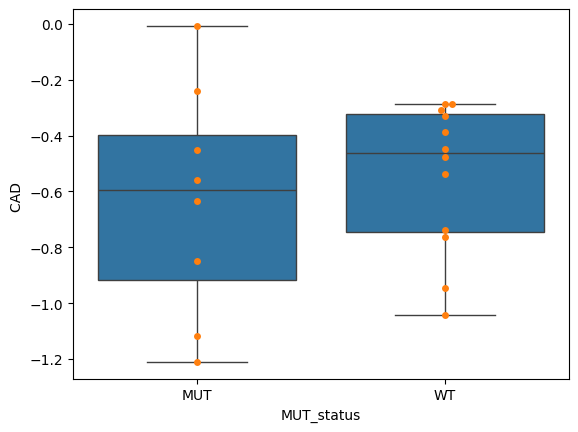

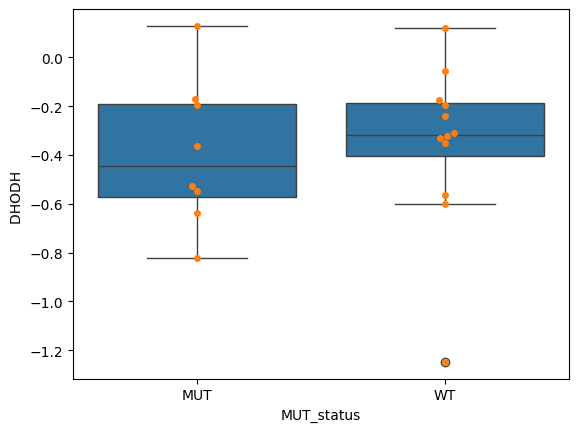

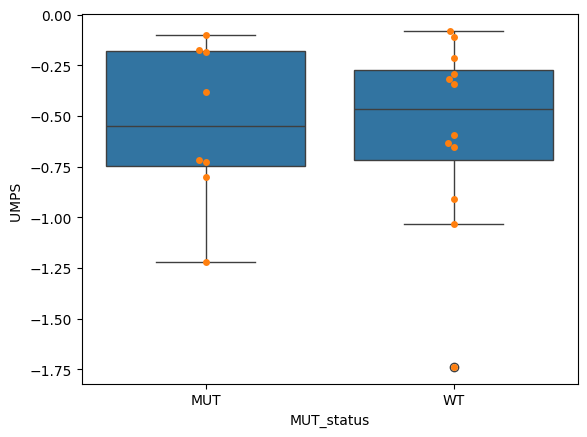

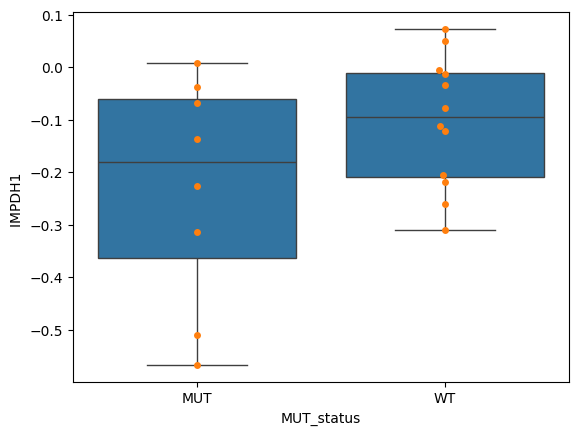

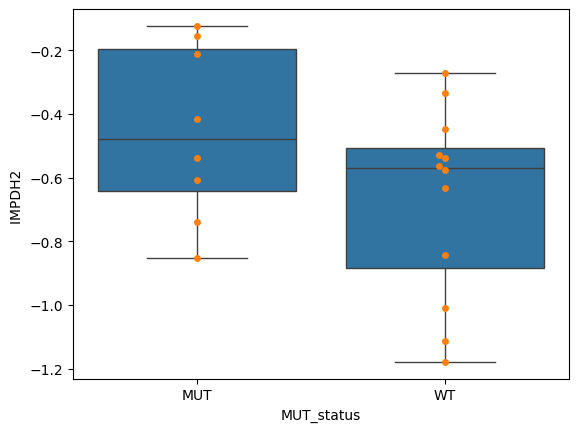

In [34]:
for i in gene_effect.iloc[:, 1:].columns:
  sns.boxplot(data = gene_effect, x = 'MUT_status', y = i)
  sns.swarmplot(data = gene_effect, x = 'MUT_status', y = i)
  plt.ylabel(i.split('(')[0])
  plt.show()

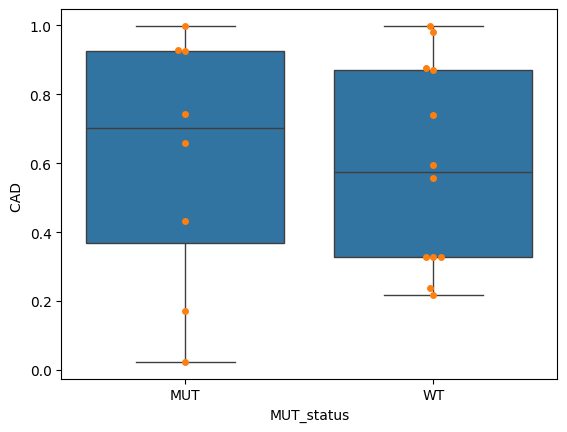

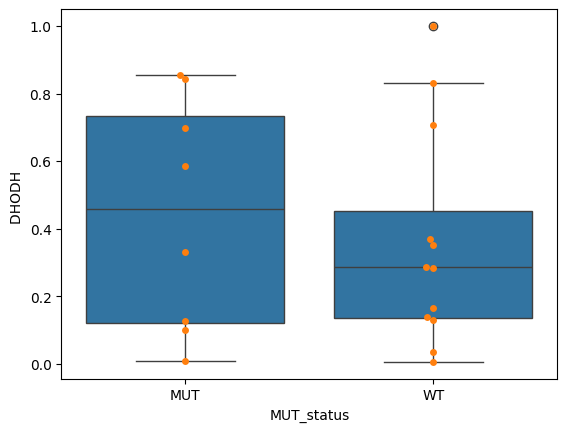

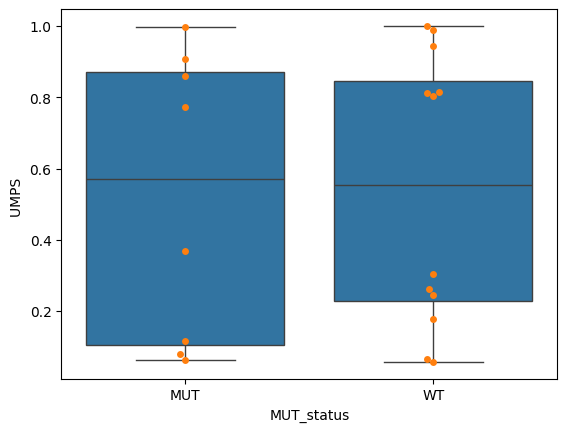

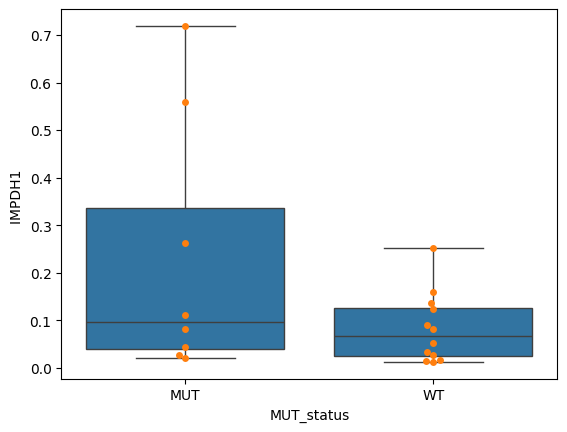

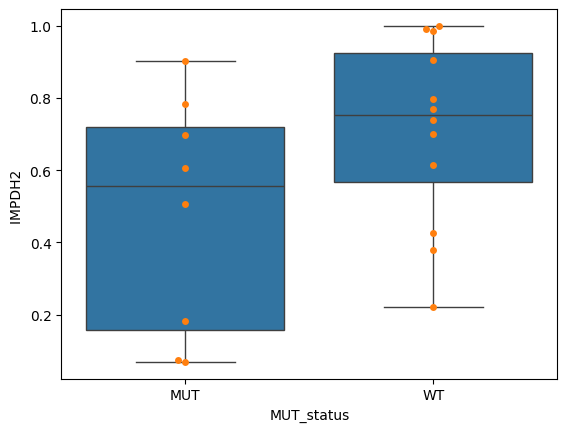

In [35]:
for i in gene_dependency.iloc[:, 1:].columns:
  sns.boxplot(data = gene_dependency, x = 'MUT_status', y = i)
  sns.swarmplot(data = gene_dependency, x = 'MUT_status', y = i)
  plt.ylabel(i.split('(')[0])
  plt.show()

In [36]:
gene_effect_grouped = gene_effect.groupby('MUT_status').median().T
gene_effect_grouped.index = [i.split('(')[0] for i in gene_effect_grouped.index]
gene_effect_grouped = gene_effect_grouped.reindex(labels = ['WT', 'MUT'], axis = 'columns')
gene_effect_grouped

MUT_status,WT,MUT
CAD,-0.462350,-0.595765
DHODH,-0.316722,-0.444385
UMPS,-0.467683,-0.549384
IMPDH1,-0.093947,-0.180783
IMPDH2,-0.569076,-0.478328


In [37]:
gene_dependency_grouped = gene_dependency.groupby('MUT_status').median().T
gene_dependency_grouped.index = [i.split('(')[0] for i in gene_dependency_grouped.index]
gene_dependency_grouped = gene_dependency_grouped.reindex(labels = ['WT', 'MUT'], axis = 'columns')
gene_dependency_grouped

MUT_status,WT,MUT
CAD,0.574855,0.700732
DHODH,0.285563,0.458212
UMPS,0.554703,0.570339
IMPDH1,0.067221,0.095488
IMPDH2,0.753325,0.556191


In [38]:
from matplotlib.colors import LinearSegmentedColormap

# colors = ["#00008B", "white", "#8B0000"]  # blue → white → red
# cmap = LinearSegmentedColormap.from_list("my_cmap", colors)
cmap = sns.color_palette("vlag", as_cmap=True)

(array([0.5, 1.5, 2.5, 3.5, 4.5]),
 [Text(0, 0.5, 'CAD '),
  Text(0, 1.5, 'DHODH '),
  Text(0, 2.5, 'UMPS '),
  Text(0, 3.5, 'IMPDH1 '),
  Text(0, 4.5, 'IMPDH2 ')])

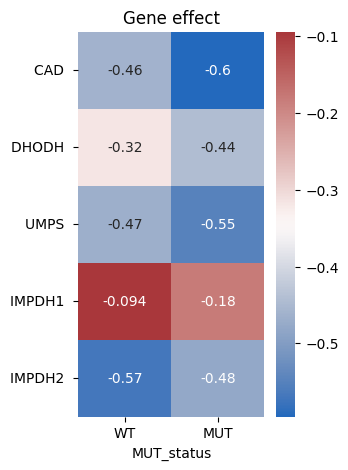

In [39]:
plt.figure(figsize = (3,5))
plt.title('Gene effect')
sns.heatmap(gene_effect_grouped, cmap = cmap, annot = True)
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/CCLE_gene_effect.svg', bbox_inches = 'tight')
plt.yticks(rotation = 0)

(array([0.5, 1.5, 2.5, 3.5, 4.5]),
 [Text(0, 0.5, 'CAD '),
  Text(0, 1.5, 'DHODH '),
  Text(0, 2.5, 'UMPS '),
  Text(0, 3.5, 'IMPDH1 '),
  Text(0, 4.5, 'IMPDH2 ')])

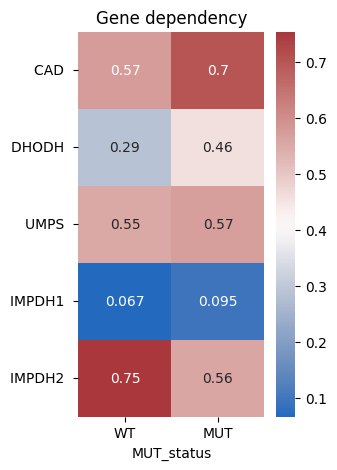

In [40]:
plt.figure(figsize = (3,5))
plt.title('Gene dependency')
sns.heatmap(gene_dependency_grouped, cmap = cmap, annot = True)
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/CCLE_gene_dependency.svg', bbox_inches = 'tight')
plt.yticks(rotation = 0)

# GSEA visualizations

In [41]:
from scipy.stats import f_oneway

gsea_stat = {}
for i in gsea.iloc[:, 1:].columns:
  stat, p_val = f_oneway(gsea[gsea['MUT_status'] == 'MUT'][i].values,
                          gsea[gsea['MUT_status'] == 'WT'][i].values)
  gsea_stat[i] = p_val
gsea_stat = pd.DataFrame(gsea_stat, index = ['p_value']).T
# gsea_stat['p_value'] = gsea_stat['p_value']/gsea_stat.shape[0]
gsea_stat

,p_value
CHEOK_RESPONSE_TO_MERCAPTOPURINE_DN,0.631970
CHEOK_RESPONSE_TO_MERCAPTOPURINE_AND_LD_MTX_UP,0.962401
CHEOK_RESPONSE_TO_MERCAPTOPURINE_UP,0.706807
CHEOK_RESPONSE_TO_MERCAPTOPURINE_AND_LD_MTX_DN,0.457867
CHEOK_RESPONSE_TO_MERCAPTOPURINE_AND_HD_MTX_UP,0.362172
...,...
WP_PYRIMIDINE_METABOLISM_AND_RELATED_DISEASES,0.570988
WP_PURINE_METABOLISM_AND_RELATED_DISORDERS,0.722823
WP_BIOMARKERS_FOR_PYRIMIDINE_METABOLISM_DISORDERS,0.390553
WP_PURINERGIC_SIGNALING,0.293141


In [42]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
gsea_grouped = gsea.groupby('MUT_status').median().T
gsea_grouped = pd.DataFrame(scaler.fit_transform(gsea_grouped), columns = gsea_grouped.columns, index = gsea_grouped.index)
gsea_grouped

MUT_status,MUT,WT
CHEOK_RESPONSE_TO_MERCAPTOPURINE_DN,0.369872,0.434322
CHEOK_RESPONSE_TO_MERCAPTOPURINE_AND_LD_MTX_UP,0.685440,0.723649
CHEOK_RESPONSE_TO_MERCAPTOPURINE_UP,0.603177,0.601143
CHEOK_RESPONSE_TO_MERCAPTOPURINE_AND_LD_MTX_DN,0.449371,0.518951
CHEOK_RESPONSE_TO_MERCAPTOPURINE_AND_HD_MTX_UP,0.910780,0.738704
...,...,...
WP_PYRIMIDINE_METABOLISM_AND_RELATED_DISEASES,0.526850,0.492211
WP_PURINE_METABOLISM_AND_RELATED_DISORDERS,0.611262,0.501573
WP_BIOMARKERS_FOR_PYRIMIDINE_METABOLISM_DISORDERS,0.651919,0.615057
WP_PURINERGIC_SIGNALING,0.435096,0.296389


In [43]:
keep_pathways = ['KEGG_PURINE_METABOLISM', 'KEGG_PYRIMIDINE_METABOLISM',
       'GO_PURINE_NUCLEOBASE_METABOLIC_PROCESS',
       'GO_PURINE_NUCLEOSIDE_CATABOLIC_PROCESS',
       'GO_PURINE_RIBONUCLEOSIDE_SALVAGE',
       'GO_PYRIMIDINE_NUCLEOBASE_METABOLIC_PROCESS',
       'GO_DE_NOVO_PYRIMIDINE_NUCLEOBASE_BIOSYNTHETIC_PROCESS',
       'GO_PYRIMIDINE_NUCLEOSIDE_METABOLIC_PROCESS',
       'GO_PYRIMIDINE_NUCLEOTIDE_METABOLIC_PROCESS',
       'GO_PYRIMIDINE_NUCLEOTIDE_BIOSYNTHETIC_PROCESS',
       'GO_PYRIMIDINE_NUCLEOTIDE_CATABOLIC_PROCESS',
       'GO_PYRIMIDINE_DIMER_REPAIR', 'GO_PURINE_NUCLEOBASE_TRANSPORT',
       'GO_PYRIMIDINE_CONTAINING_COMPOUND_SALVAGE',
       'GO_PURINE_NUCLEOBASE_BIOSYNTHETIC_PROCESS',
       'GO_PURINE_NUCLEOSIDE_MONOPHOSPHATE_METABOLIC_PROCESS',
       'GO_PURINE_NUCLEOSIDE_MONOPHOSPHATE_BIOSYNTHETIC_PROCESS',
       'GO_PYRIMIDINE_NUCLEOSIDE_MONOPHOSPHATE_METABOLIC_PROCESS',
       'GO_PURINE_NUCLEOSIDE_TRIPHOSPHATE_METABOLIC_PROCESS',
       'GO_PURINE_NUCLEOSIDE_TRIPHOSPHATE_CATABOLIC_PROCESS',
       'GO_PYRIMIDINE_NUCLEOSIDE_TRIPHOSPHATE_METABOLIC_PROCESS',
       'GO_PYRIMIDINE_NUCLEOSIDE_TRIPHOSPHATE_BIOSYNTHETIC_PROCESS',
       'GO_PURINE_DEOXYRIBONUCLEOTIDE_METABOLIC_PROCESS',
       'GO_PURINE_DEOXYRIBONUCLEOTIDE_BIOSYNTHETIC_PROCESS',
       'GO_PURINE_DEOXYRIBONUCLEOTIDE_CATABOLIC_PROCESS',
       'GO_PYRIMIDINE_RIBONUCLEOSIDE_MONOPHOSPHATE_METABOLIC_PROCESS',
       'GO_PYRIMIDINE_DEOXYRIBONUCLEOSIDE_MONOPHOSPHATE_METABOLIC_PROCESS',
       'GO_PYRIMIDINE_DEOXYRIBONUCLEOSIDE_MONOPHOSPHATE_BIOSYNTHETIC_PROCESS',
       'GO_PYRIMIDINE_RIBONUCLEOSIDE_TRIPHOSPHATE_METABOLIC_PROCESS',
       'GO_PYRIMIDINE_DEOXYRIBONUCLEOSIDE_TRIPHOSPHATE_METABOLIC_PROCESS',
       'GO_PURINE_DEOXYRIBONUCLEOSIDE_TRIPHOSPHATE_METABOLIC_PROCESS',
       'GO_PURINE_DEOXYRIBONUCLEOSIDE_TRIPHOSPHATE_CATABOLIC_PROCESS',
       'GO_PYRIMIDINE_RIBONUCLEOTIDE_METABOLIC_PROCESS',
       'GO_PYRIMIDINE_DEOXYRIBONUCLEOTIDE_METABOLIC_PROCESS',
       'GO_PYRIMIDINE_DEOXYRIBONUCLEOTIDE_BIOSYNTHETIC_PROCESS',
       'GO_RESPONSE_TO_PURINE_CONTAINING_COMPOUND',
       'GO_PYRIMIDINE_NUCLEOBASE_TRANSPORT',
       'GO_PYRIMIDINE_NUCLEOSIDE_TRANSPORT', 'GO_PURINE_NUCLEOTIDE_TRANSPORT',
       'GO_PYRIMIDINE_NUCLEOBASE_BIOSYNTHETIC_PROCESS',
       'GO_PURINE_NUCLEOTIDE_SALVAGE', 'GO_PYRIMIDINE_NUCLEOTIDE_SALVAGE',
       'GO_G_PROTEIN_COUPLED_PURINERGIC_RECEPTOR_SIGNALING_PATHWAY',
       'GO_G_PROTEIN_COUPLED_PURINERGIC_NUCLEOTIDE_RECEPTOR_SIGNALING_PATHWAY',
       'GO_PURINERGIC_NUCLEOTIDE_RECEPTOR_SIGNALING_PATHWAY',
       'GO_PURINE_NUCLEOSIDE_METABOLIC_PROCESS',
       'GO_PURINE_NUCLEOSIDE_BIOSYNTHETIC_PROCESS',
       'GO_PURINE_CONTAINING_COMPOUND_SALVAGE',
       'GO_PYRIMIDINE_DEOXYRIBONUCLEOSIDE_METABOLIC_PROCESS',
       'GO_PYRIMIDINE_RIBONUCLEOSIDE_METABOLIC_PROCESS',
       'GO_PYRIMIDINE_NUCLEOSIDE_BIOSYNTHETIC_PROCESS',
       'GO_PYRIMIDINE_NUCLEOSIDE_CATABOLIC_PROCESS',
       'GO_CELLULAR_RESPONSE_TO_PURINE_CONTAINING_COMPOUND',
       'GO_PURINE_CONTAINING_COMPOUND_METABOLIC_PROCESS',
       'GO_PURINE_CONTAINING_COMPOUND_BIOSYNTHETIC_PROCESS',
       'GO_PURINE_CONTAINING_COMPOUND_CATABOLIC_PROCESS',
       'GO_PYRIMIDINE_CONTAINING_COMPOUND_METABOLIC_PROCESS',
       'GO_PYRIMIDINE_CONTAINING_COMPOUND_BIOSYNTHETIC_PROCESS',
       'GO_PYRIMIDINE_CONTAINING_COMPOUND_CATABOLIC_PROCESS',
       'GO_PURINE_CONTAINING_COMPOUND_TRANSMEMBRANE_TRANSPORT',
       'GO_PYRIMIDINE_CONTAINING_COMPOUND_TRANSMEMBRANE_TRANSPORT',
       'GO_PURINE_NUCLEOBASE_TRANSMEMBRANE_TRANSPORTER_ACTIVITY',
       'GO_POLY_PYRIMIDINE_TRACT_BINDING',
       'GO_PYRIMIDINE_NUCLEOTIDE_SUGAR_TRANSMEMBRANE_TRANSPORTER_ACTIVITY',
       'GO_PYRIMIDINE_NUCLEOSIDE_TRANSMEMBRANE_TRANSPORTER_ACTIVITY',
       'GO_PYRIMIDINE_NUCLEOTIDE_BINDING',
       'GO_PURINE_DEOXYRIBONUCLEOTIDE_BINDING',
       'GO_G_PROTEIN_COUPLED_PURINERGIC_NUCLEOTIDE_RECEPTOR_ACTIVITY',
       'GO_POLY_PURINE_TRACT_BINDING',
       'HP_ABNORMAL_CIRCULATING_PURINE_CONCENTRATION',
       'HP_INCREASED_PURINE_LEVEL',
       'REACTOME_PYRIMIDINE_SALVAGE', 'REACTOME_PYRIMIDINE_CATABOLISM',
       'REACTOME_PURINE_RIBONUCLEOSIDE_MONOPHOSPHATE_BIOSYNTHESIS',
       'REACTOME_PURINE_SALVAGE', 'REACTOME_PURINE_CATABOLISM',
       'REACTOME_TRANSPORT_OF_NUCLEOSIDES_AND_FREE_PURINE_AND_PYRIMIDINE_BASES_ACROSS_THE_PLASMA_MEMBRANE',
       'WP_PYRIMIDINE_METABOLISM', 'WP_PYRIMIDINE_METABOLISM_AND_RELATED_DISEASES', 'WP_PURINE_METABOLISM']

In [44]:
gsea_grouped = gsea_grouped.loc[keep_pathways]

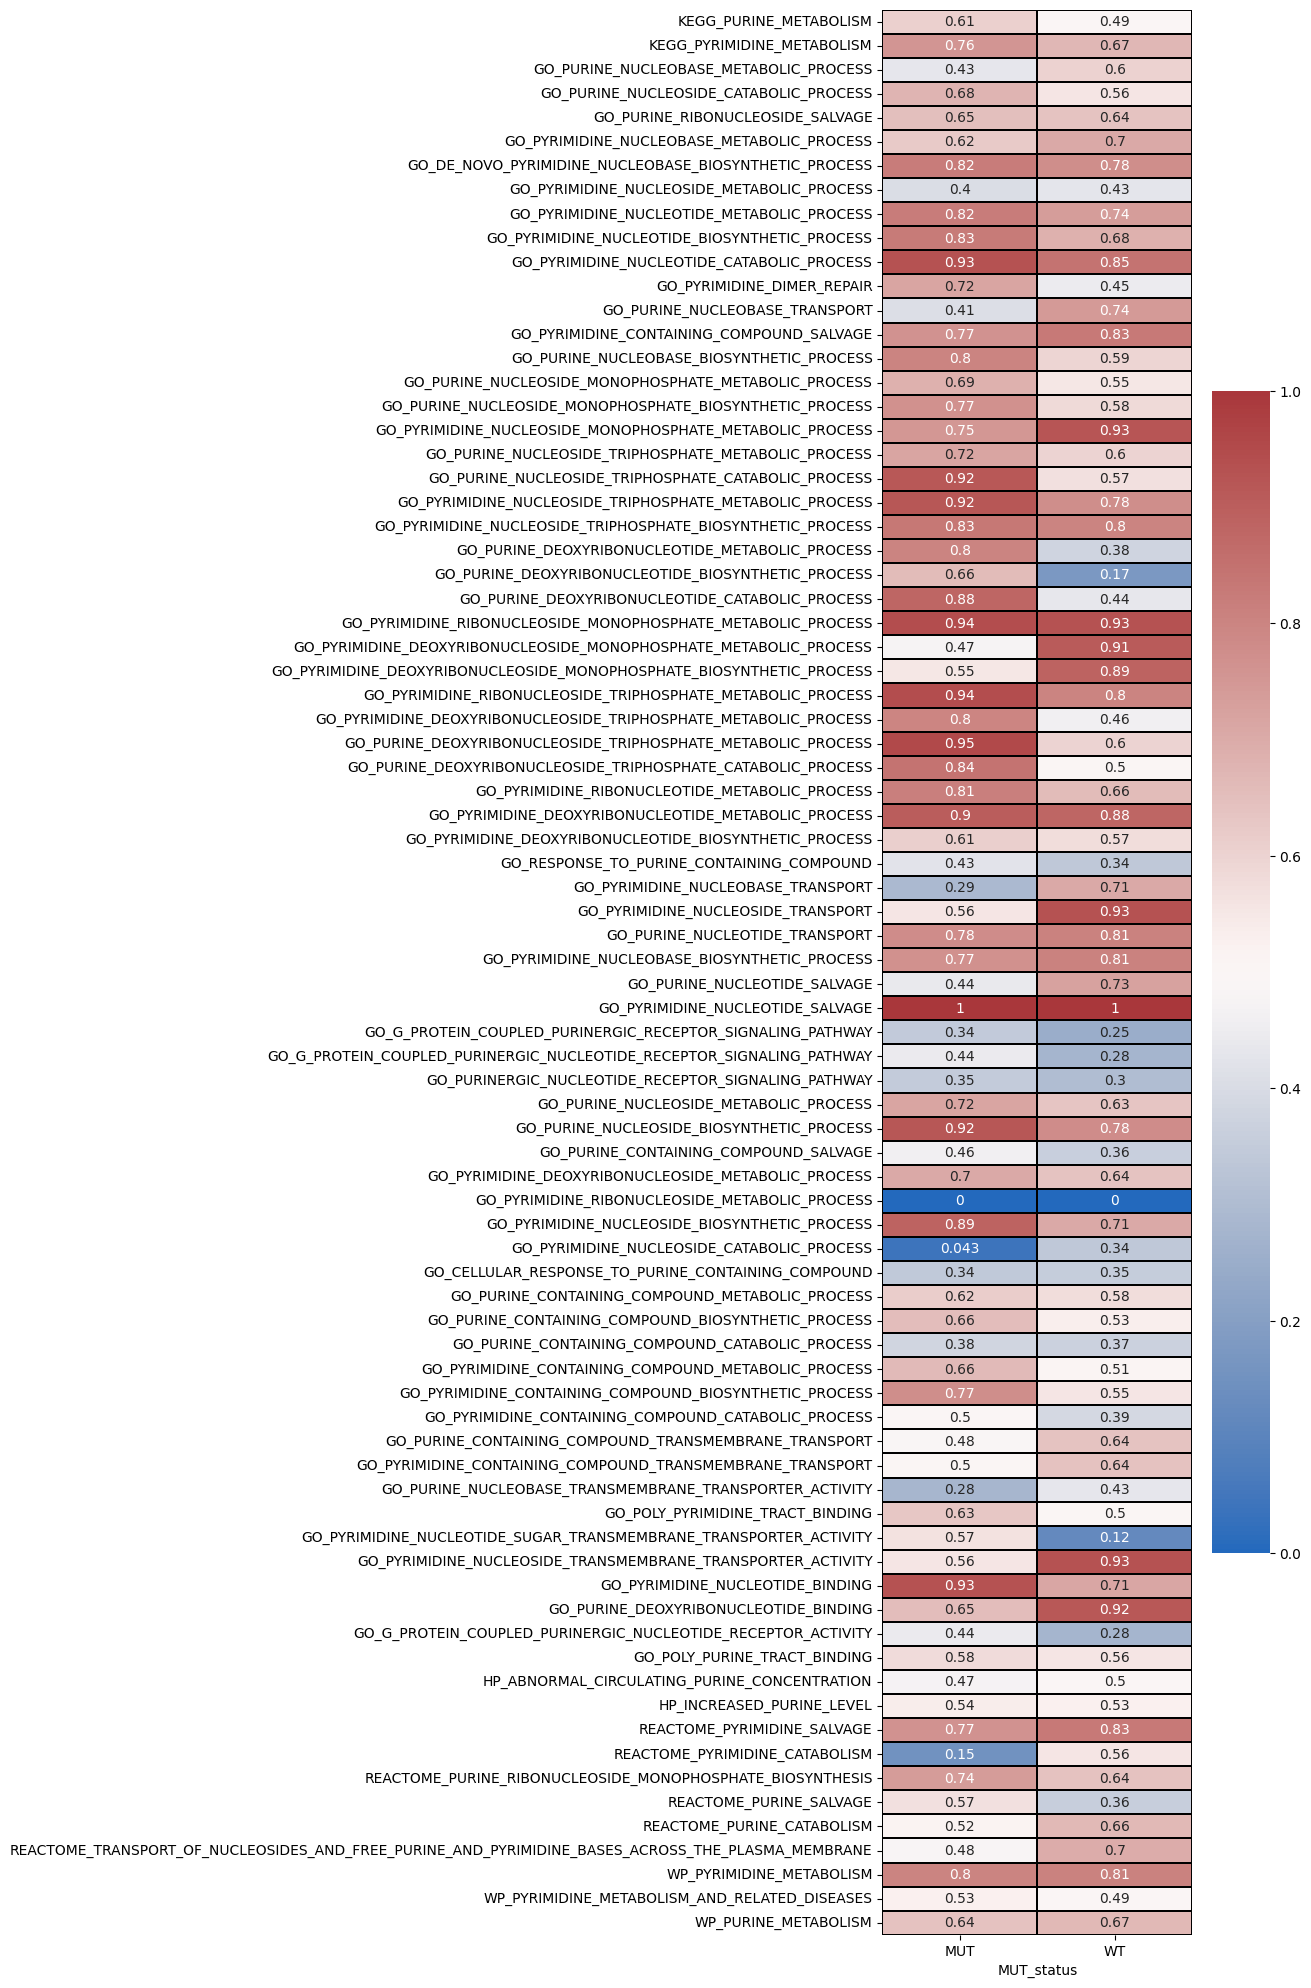

In [45]:
plt.figure(figsize = (5,25))
sns.heatmap(gsea_grouped, cmap = cmap, linewidths = 0.05, linecolor='black', annot = True)
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/CCLE_heamtap_GSEA.svg', bbox_inches = 'tight')

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


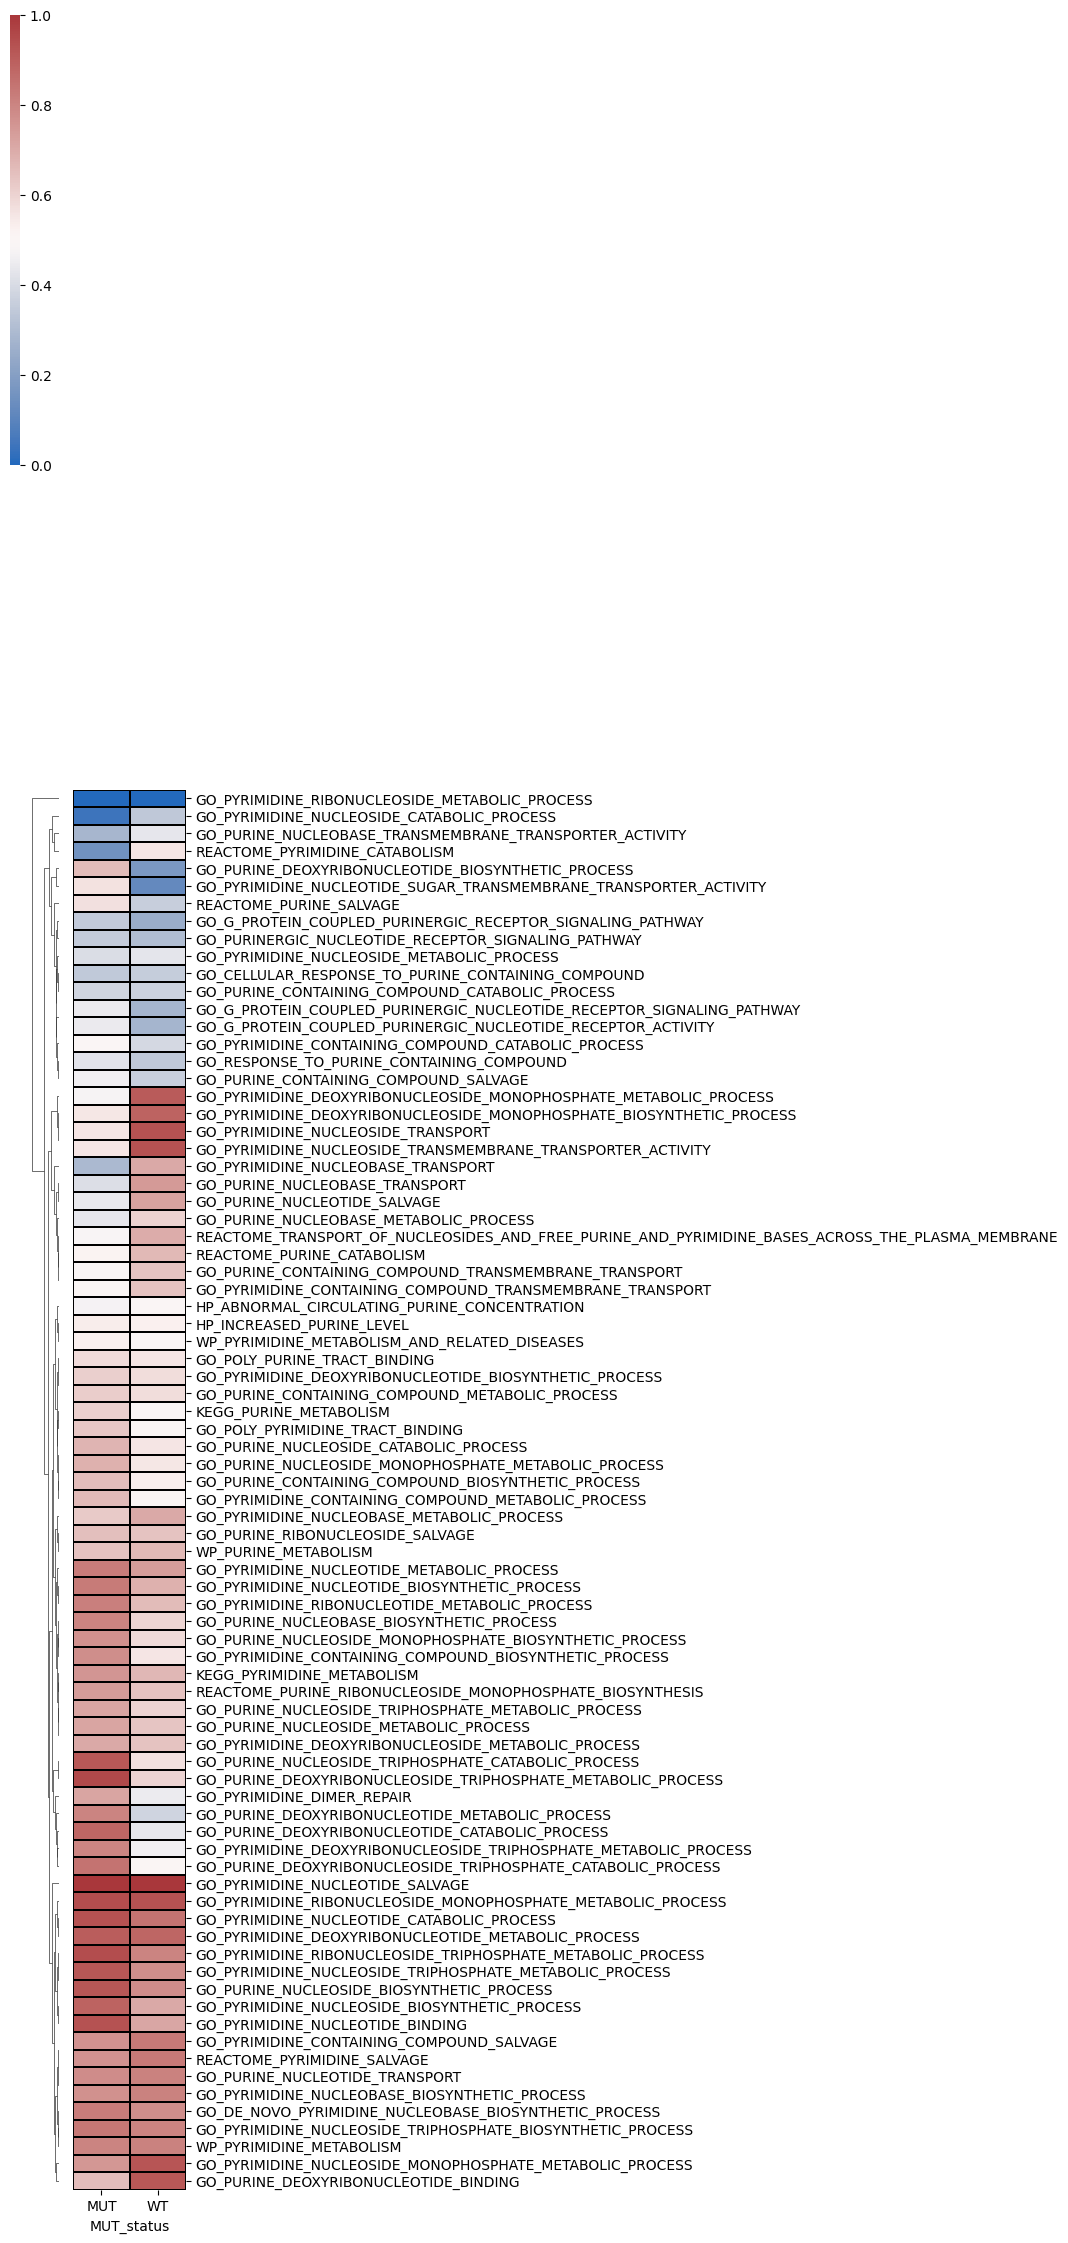

In [46]:
g = sns.clustermap(gsea_grouped, cmap = cmap, figsize = (2,25), col_cluster = False, linewidths = 0.05, linecolor='black')
g.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/CCLE_clustermap_GSEA.svg', format='svg')

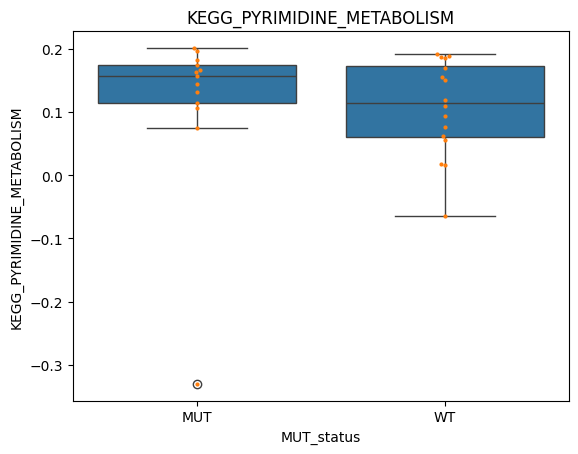

In [47]:
plt.title('KEGG_PYRIMIDINE_METABOLISM')
sns.boxplot(gsea, x = 'MUT_status', y = 'KEGG_PYRIMIDINE_METABOLISM')
sns.swarmplot(gsea, x = 'MUT_status', y = 'KEGG_PYRIMIDINE_METABOLISM', s = 3)
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/CCLE_KEGG_pyrimidine_box_plot.svg', bbox_inches = 'tight')

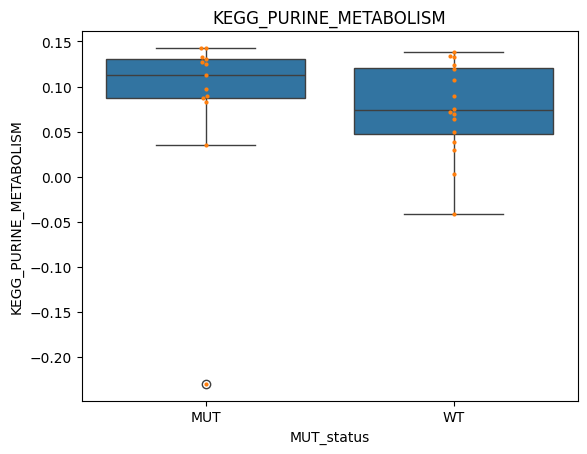

In [48]:
plt.title('KEGG_PURINE_METABOLISM')
sns.boxplot(gsea, x = 'MUT_status', y = 'KEGG_PURINE_METABOLISM')
sns.swarmplot(gsea, x = 'MUT_status', y = 'KEGG_PURINE_METABOLISM', s = 3)
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/CCLE_KEGG_purine_box_plot.svg', bbox_inches = 'tight')

#Metabolomics visualizations

In [49]:
metabolomics.head(3)

,MUT_status,2-aminoadipate,3-phosphoglycerate,alpha-glycerophosphate,4-pyridoxate,aconitate,adenine,adipate,alpha-ketoglutarate,AMP,...,C56:8 TAG,C56:7 TAG,C56:6 TAG,C56:5 TAG,C56:4 TAG,C56:3 TAG,C56:2 TAG,C58:8 TAG,C58:7 TAG,C58:6 TAG
ACH-000927,MUT,5.537100,5.728618,5.735934,5.983348,5.678932,5.603314,5.984889,5.782545,6.050206,...,6.077318,5.819687,5.887620,5.736615,5.847289,5.536305,5.415971,5.965816,5.942640,6.010368
ACH-000276,MUT,5.734549,5.741243,5.726934,5.558014,5.837319,6.174542,5.922278,5.751083,5.778905,...,5.820197,5.677272,6.063834,6.202897,6.425648,6.211892,6.210392,5.923512,5.915983,6.130336
ACH-000097,MUT,5.666087,6.212810,6.223117,6.116608,6.021599,6.018505,5.875382,6.097603,6.608236,...,5.776225,5.602235,5.733102,5.669476,5.921573,6.236516,6.380548,5.537621,5.940163,5.498613


In [50]:
from sklearn.preprocessing import MinMaxScaler

scaler_metabolomics = MinMaxScaler()
metabolomics_scaled = pd.DataFrame(scaler_metabolomics.fit_transform(metabolomics.iloc[:, 1:]), columns = metabolomics.iloc[:, 1:].columns, index = metabolomics.iloc[:, 1:].index)
metabolomics_scaled = pd.concat([metabolomics['MUT_status'], metabolomics_scaled], axis = 'columns')
metabolomics_scaled

,MUT_status,2-aminoadipate,3-phosphoglycerate,alpha-glycerophosphate,4-pyridoxate,aconitate,adenine,adipate,alpha-ketoglutarate,AMP,...,C56:8 TAG,C56:7 TAG,C56:6 TAG,C56:5 TAG,C56:4 TAG,C56:3 TAG,C56:2 TAG,C58:8 TAG,C58:7 TAG,C58:6 TAG
ACH-000927,MUT,0.163364,0.423667,0.503261,0.309739,0.589360,0.359111,0.524389,0.465440,0.499643,...,0.723730,0.314700,0.390975,0.368870,0.279388,0.033334,0.077169,0.484321,0.477839,0.462685
ACH-000276,MUT,0.391550,0.432399,0.499801,0.072761,0.740163,0.801872,0.415436,0.435968,0.256381,...,0.550885,0.224257,0.502798,0.594732,0.551525,0.508767,0.546991,0.462697,0.465849,0.524686
ACH-000097,MUT,0.312430,0.758551,0.690546,0.383985,0.915618,0.680927,0.333830,0.760570,1.000000,...,0.521326,0.176604,0.292919,0.336349,0.314341,0.526095,0.647622,0.265444,0.476725,0.198199
ACH-000277,WT,0.000000,0.662754,0.681632,0.517344,0.850526,0.854317,0.000000,0.514156,0.557477,...,0.247892,0.364939,0.334345,0.296533,0.110113,0.221491,0.345570,0.000000,0.287311,0.202235
ACH-000374,WT,0.514133,0.000000,0.289638,0.228506,0.562718,0.226760,0.507087,0.223680,0.000000,...,0.406521,0.373107,0.475904,0.506147,0.360597,0.275287,0.397589,0.481741,0.494314,0.432002
ACH-000699,WT,0.795299,0.187350,0.413709,0.442107,0.024030,0.487380,0.412263,0.339841,0.003275,...,0.704136,0.801126,0.837780,0.712075,0.479590,0.334229,0.371205,0.891333,1.000000,0.809361
ACH-000721,WT,1.000000,0.449733,0.171518,0.485307,0.000000,1.000000,0.481554,0.000000,0.284769,...,0.961453,0.898258,0.933350,0.849645,0.601071,0.845630,0.793595,0.847754,0.937563,0.829414
ACH-000536,MUT,0.915421,0.535734,0.577878,0.416061,1.000000,0.644940,0.679957,1.000000,0.569697,...,0.492774,0.169910,0.290947,0.375283,0.134728,0.122640,0.336834,0.216468,0.227833,0.316717
ACH-000668,MUT,0.481983,0.677469,0.460628,0.320296,0.703128,0.588292,0.506900,0.483472,0.516375,...,0.365436,0.697825,0.262210,0.470658,0.348924,0.140048,0.000000,0.453682,0.292942,0.213661
ACH-000111,WT,0.006007,0.489902,0.421485,0.281733,0.017388,0.301424,0.435072,0.130433,0.325720,...,0.551442,1.000000,1.000000,1.000000,1.000000,1.000000,0.999353,1.000000,0.873411,1.000000


In [51]:
stat_res = {}
for i in metabolomics_scaled.iloc[:, 1:].columns:
  stat, p_val = f_oneway(metabolomics_scaled[metabolomics_scaled['MUT_status'] == 'WT'][i].values,
                         metabolomics_scaled[metabolomics_scaled['MUT_status'] == 'MUT'][i].values)
  stat_res[i] = p_val
stat_res = pd.DataFrame(stat_res, index = ['p_value']).T.sort_values(by = 'p_value', ascending = False)
stat_res

,p_value
alpha-glycerophosphocholine,0.987777
serine,0.987097
hexoses (HILIC neg),0.984197
2-hydroxyglutarate,0.975858
pipecolic acid,0.975159
...,...
acetylcarnitine,0.020633
AMP,0.018236
GABA,0.014268
aconitate,0.010628


In [52]:
met_sig = stat_res[stat_res['p_value'] < 0.05].index.to_list()
len(met_sig)

12

In [53]:
metabolomics_scaled.MUT_status.value_counts()

,count
MUT_status,
MUT,11
WT,11


In [54]:
metabolomics_grouped = metabolomics_scaled.groupby('MUT_status').median().T
metabolomics_grouped

MUT_status,MUT,WT
2-aminoadipate,0.353185,0.668049
3-phosphoglycerate,0.535734,0.489902
alpha-glycerophosphate,0.503261,0.419858
4-pyridoxate,0.309739,0.409700
aconitate,0.740163,0.434320
...,...,...
C56:3 TAG,0.508767,0.334229
C56:2 TAG,0.421957,0.397589
C58:8 TAG,0.453682,0.500559
C58:7 TAG,0.465849,0.590372


In [55]:
metabolomics_grouped['log2FC'] = np.log2(metabolomics_grouped['MUT'] / metabolomics_grouped['WT'])
metabolomics_grouped

MUT_status,MUT,WT,log2FC
2-aminoadipate,0.353185,0.668049,-0.919530
3-phosphoglycerate,0.535734,0.489902,0.129023
alpha-glycerophosphate,0.503261,0.419858,0.261405
4-pyridoxate,0.309739,0.409700,-0.403516
aconitate,0.740163,0.434320,0.769084
...,...,...,...
C56:3 TAG,0.508767,0.334229,0.606168
C56:2 TAG,0.421957,0.397589,0.085816
C58:8 TAG,0.453682,0.500559,-0.141859
C58:7 TAG,0.465849,0.590372,-0.341763


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


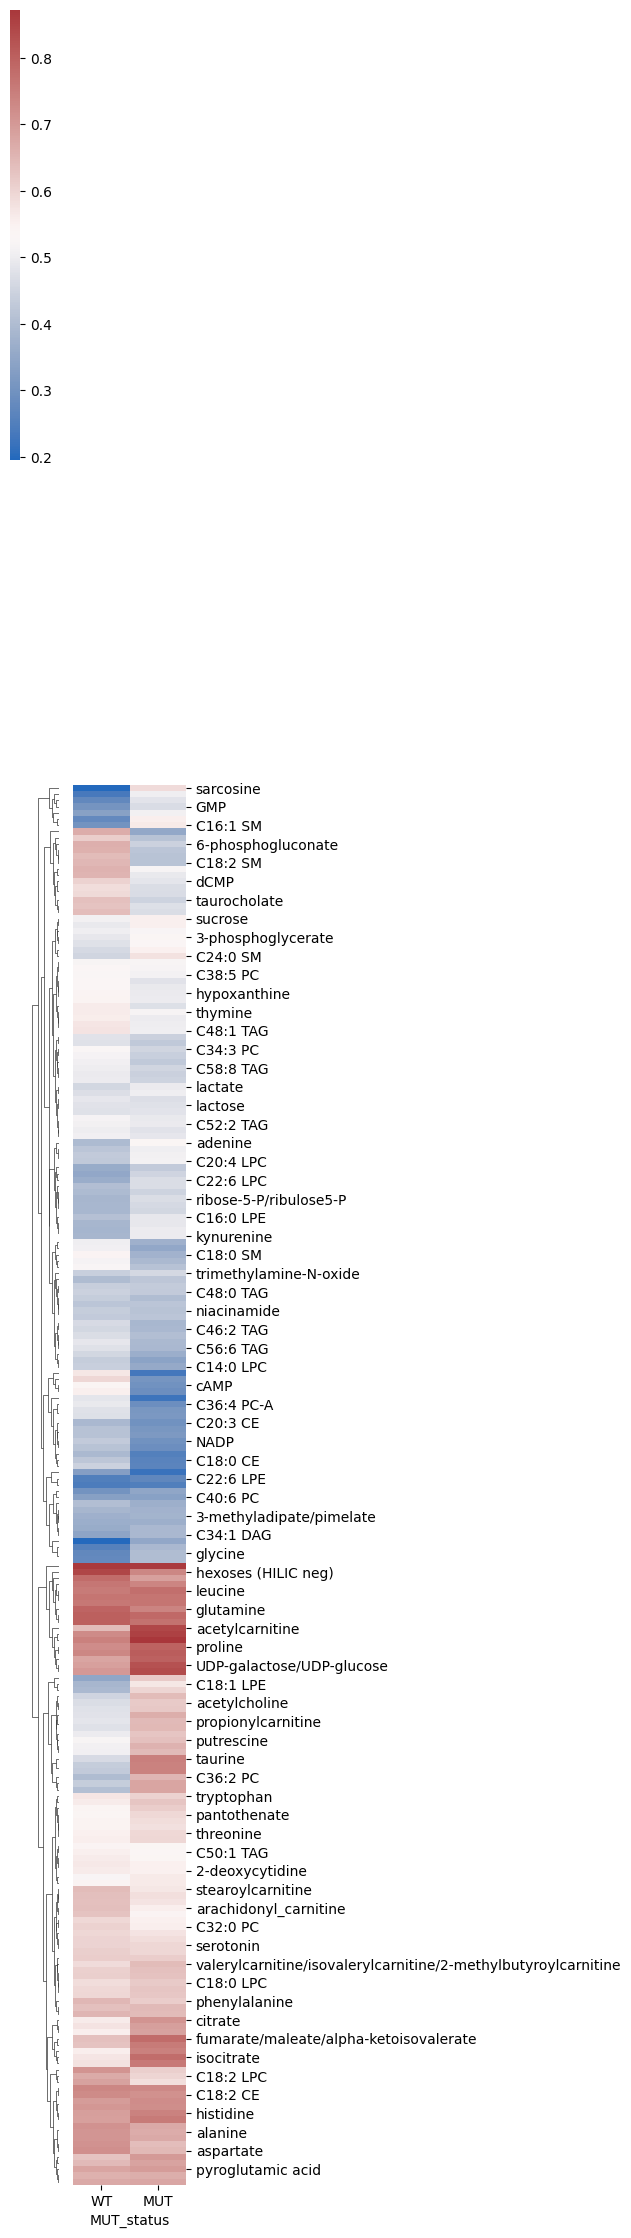

In [56]:
g = sns.clustermap(metabolomics_grouped[['WT', 'MUT']], cmap = cmap, figsize = (2,25), col_cluster = False)

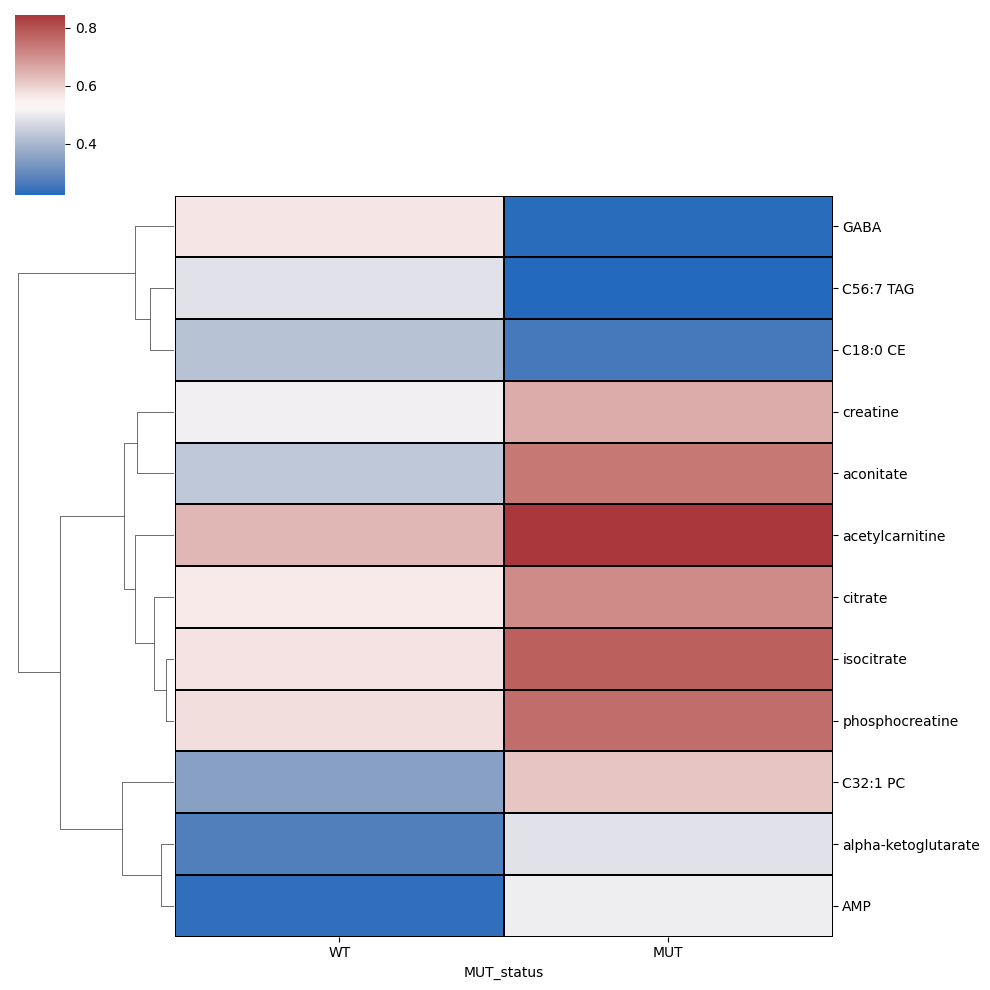

In [57]:
g = sns.clustermap(metabolomics_grouped.loc[met_sig][['WT', 'MUT']], cmap = cmap, col_cluster = False, linewidths = 0.05, linecolor='black')

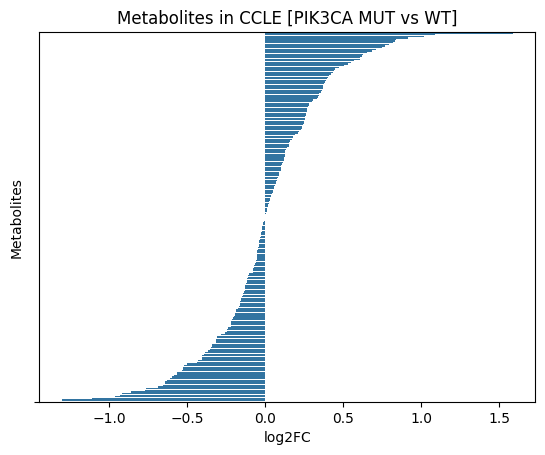

In [58]:
sns.barplot(data = metabolomics_grouped.sort_values(by = 'log2FC', ascending = False), y = metabolomics_grouped.index, x = 'log2FC')
plt.title('Metabolites in CCLE [PIK3CA MUT vs WT]')
plt.yticks([''])
plt.ylabel('Metabolites')
plt.show()

In [59]:
map_names = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/CCLE_name_map.csv')
map_names

,Query,Match,HMDB,PubChem,ChEBI,KEGG,METLIN,SMILES,Comment
0,2-aminoadipate,Aminoadipic acid,HMDB0000510,92136.0,37023.0,C00956,5496.0,N[C@@H](CCCC(O)=O)C(O)=O,1
1,3-phosphoglycerate,3-Phosphoglyceric acid,HMDB0000807,724.0,17050.0,C00597,150.0,OC(COP(O)(O)=O)C(O)=O,1
2,alpha-glycerophosphate,Glycerol 3-phosphate,HMDB0000126,439162.0,15978.0,C00093,5161.0,OC[C@@H](O)COP(O)(O)=O,1
3,4-pyridoxate,4-Pyridoxic acid,HMDB0000017,6723.0,17405.0,C00847,239.0,CC1=NC=C(CO)C(C(O)=O)=C1O,1
4,aconitate,cis-Aconitic acid,HMDB0000072,643757.0,32805.0,C00417,5130.0,OC(=O)C\C(=C\C(O)=O)C(O)=O,1
...,...,...,...,...,...,...,...,...,...
220,C56:3 TAG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
221,C56:2 TAG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
222,C58:8 TAG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
223,C58:7 TAG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [60]:
map_hmbd_names = dict(zip( map_names['HMDB'], map_names['Query']))
map_hmbd_names

{'HMDB0000510': '2-aminoadipate',
 'HMDB0000807': '3-phosphoglycerate',
 'HMDB0000126': 'alpha-glycerophosphate',
 'HMDB0000017': '4-pyridoxate',
 'HMDB0000072': 'aconitate',
 'HMDB0000034': 'adenine',
 'HMDB0000448': 'adipate',
 'HMDB0000208': 'alpha-ketoglutarate',
 'HMDB0000045': 'AMP',
 'HMDB0000094': 'citrate',
 'HMDB0000193': 'isocitrate',
 'HMDB0000095': 'CMP',
 'HMDB0000099': 'cystathionine',
 'HMDB0000089': 'cytidine',
 'HMDB0001202': 'dCMP',
 nan: 'C58:6 TAG',
 'HMDB0001321': 'erythrose-4-phosphate',
 'HMDB0000127': 'glucuronate',
 'HMDB0000125': 'glutathione reduced',
 'HMDB0001397': 'GMP',
 'HMDB0000133': 'guanosine',
 'HMDB0000714': 'hippurate',
 'HMDB0000157': 'hypoxanthine',
 'HMDB0000195': 'inosine',
 'HMDB0000684': 'kynurenine',
 'HMDB0000190': 'lactate',
 'HMDB0000186': 'lactose',
 'HMDB0000156': 'malate',
 'HMDB0000902': 'NAD',
 'HMDB0000217': 'NADP',
 'HMDB0002329': 'oxalate',
 'HMDB0000210': 'pantothenate',
 'HMDB0000263': 'PEP',
 'HMDB0000247': 'sorbitol',
 'HMDB0

In [61]:
map_names_dict = dict(zip(map_names['Query'], map_names['HMDB']))
map_names_dict

{'2-aminoadipate': 'HMDB0000510',
 '3-phosphoglycerate': 'HMDB0000807',
 'alpha-glycerophosphate': 'HMDB0000126',
 '4-pyridoxate': 'HMDB0000017',
 'aconitate': 'HMDB0000072',
 'adenine': 'HMDB0000034',
 'adipate': 'HMDB0000448',
 'alpha-ketoglutarate': 'HMDB0000208',
 'AMP': 'HMDB0000045',
 'citrate': 'HMDB0000094',
 'isocitrate': 'HMDB0000193',
 'CMP': 'HMDB0000095',
 'cystathionine': 'HMDB0000099',
 'cytidine': 'HMDB0000089',
 'dCMP': 'HMDB0001202',
 'DHAP/glyceraldehyde 3P': nan,
 'erythrose-4-phosphate': 'HMDB0001321',
 'F1P/F6P/G1P/G6P': nan,
 'hexoses (HILIC neg)': nan,
 'fumarate/maleate/alpha-ketoisovalerate': nan,
 'glucuronate': 'HMDB0000127',
 'glutathione oxidized': nan,
 'glutathione reduced': 'HMDB0000125',
 'GMP': 'HMDB0001397',
 'guanosine': 'HMDB0000133',
 'hippurate': 'HMDB0000714',
 'hypoxanthine': 'HMDB0000157',
 'inosine': 'HMDB0000195',
 'kynurenine': 'HMDB0000684',
 'lactate': 'HMDB0000190',
 'lactose': 'HMDB0000186',
 'malate': 'HMDB0000156',
 'NAD': 'HMDB000090

In [62]:
metabolomics_grouped_hmdb = metabolomics_grouped.reset_index()
metabolomics_grouped_hmdb['index'] = metabolomics_grouped_hmdb['index'].map(map_names_dict)
metabolomics_grouped_hmdb = metabolomics_grouped_hmdb.dropna()
metabolomics_grouped_hmdb = metabolomics_grouped_hmdb.set_index('index')
metabolomics_grouped_hmdb

MUT_status,MUT,WT,log2FC
index,,,
HMDB0000510,0.353185,0.668049,-0.919530
HMDB0000807,0.535734,0.489902,0.129023
HMDB0000126,0.503261,0.419858,0.261405
HMDB0000017,0.309739,0.409700,-0.403516
HMDB0000072,0.740163,0.434320,0.769084
...,...,...,...
HMDB0000222,0.549763,0.593805,-0.111180
HMDB0000848,0.569487,0.641889,-0.172661
HMDB0000271,0.587427,0.195601,1.586495


In [63]:
mets_ccle = {}
mets_up = metabolomics_grouped_hmdb[metabolomics_grouped_hmdb['log2FC'] > 0].index.to_list()
mets_down = metabolomics_grouped_hmdb[metabolomics_grouped_hmdb['log2FC'] < 0].index.to_list()
mets_ccle['up'] = mets_up
mets_ccle['down'] = mets_down
print(len(mets_ccle['up']))
print(len(mets_ccle['down']))

68
45


In [64]:
import pickle
with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/tcga_mets_up_down.pkl', 'rb') as f:
    mets_tcga = pickle.load(f)
print(len(mets_tcga['up']))
print(len(mets_tcga['down']))

36
33


In [65]:
mets_ccle_total = mets_ccle['up'] + mets_ccle['down']
mets_tcga_total = mets_tcga['up'] + mets_tcga['down']
mets_total_common = list(set(mets_ccle_total).intersection(set(mets_tcga_total)))
len(mets_total_common)

37

In [66]:
from matplotlib_venn import venn2

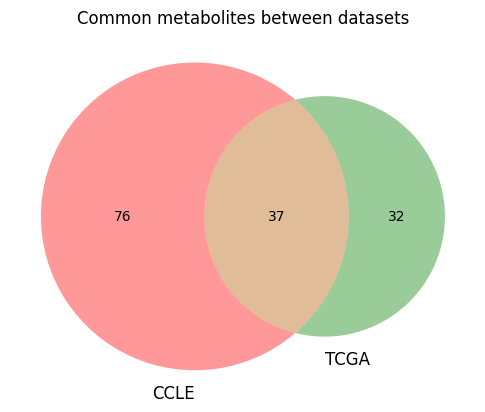

In [67]:
plt.title('Common metabolites between datasets')
venn2([set(mets_ccle_total), set(mets_tcga_total)], set_labels = ('CCLE', 'TCGA'))
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/CCLE_TCGA_common_metabolites.svg', bbox_inches = 'tight')
plt.show()

In [68]:
print('Before')
print(len(mets_ccle['up']))
print(len(mets_ccle['down']))

for key in mets_ccle.keys():
    mets_ccle[key] = [j for j in mets_ccle[key] if j in mets_total_common]

print('After')
print(len(mets_ccle['up']))
print(len(mets_ccle['down']))

Before
68
45
After
24
13


In [69]:
print('Before')
print(len(mets_tcga['up']))
print(len(mets_tcga['down']))

for key in mets_tcga.keys():
    mets_tcga[key] = [j for j in mets_tcga[key] if j in mets_total_common]

print('After')
print(len(mets_tcga['up']))
print(len(mets_tcga['down']))

Before
36
33
After
21
16


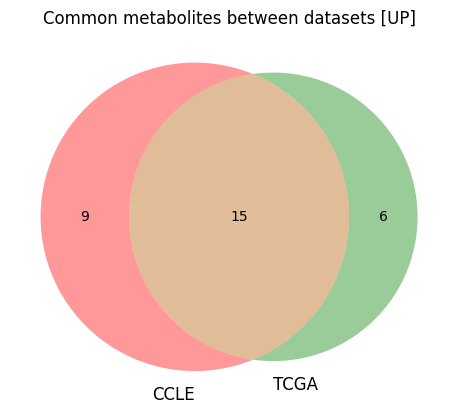

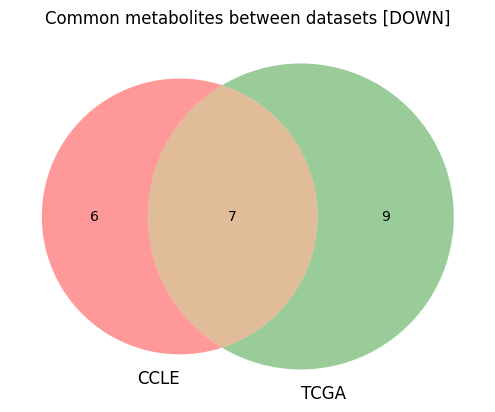

In [70]:
plt.title('Common metabolites between datasets [UP]')
venn2([set(mets_ccle['up']), set(mets_tcga['up'])], set_labels = ('CCLE', 'TCGA'))
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/CCLE_TCGA_common_UP_metabolites.svg', bbox_inches = 'tight')
plt.show()

plt.title('Common metabolites between datasets [DOWN]')
venn2([set(mets_ccle['down']), set(mets_tcga['down'])], set_labels = ('CCLE', 'TCGA'))
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/CCLE_TCGA_common_DOWN_metabolites.svg', bbox_inches = 'tight')
plt.show()

In [71]:
both = list(set(mets_ccle['up']).intersection(set(mets_tcga['up']))) + list(set(mets_ccle['down']).intersection(set(mets_tcga['down'])))
print(len(both))

22


In [72]:
tcga_log2fc = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/log2FC_tcga.csv', index_col = 0)
tcga_log2fc

,log2FC
HMDB0000071,1.353015
HMDB0000517,0.946148
HMDB0000211,0.915630
HMDB0000848,0.323659
HMDB0000929,0.290592
...,...
HMDB0003229,-0.160863
HMDB0000625,-0.203010
HMDB0000182,-0.225576
HMDB0000532,-0.349350


In [73]:
log2fc = pd.concat([metabolomics_grouped_hmdb.loc[both][['log2FC']].rename(columns = {'log2FC' : 'CCLE'}),
                    tcga_log2fc.loc[both].rename(columns = {'log2FC' : 'TCGA'})],
                   axis = 'columns')
log2fc

,CCLE,TCGA
HMDB0000517,0.073223,0.946148
HMDB0000126,0.261405,0.071399
HMDB0000929,0.077686,0.290592
HMDB0000089,0.006244,0.049012
HMDB0000177,0.100398,0.017115
HMDB0000714,0.010350,0.024858
HMDB0000210,0.150686,0.190163
HMDB0000562,0.135106,0.023789
HMDB0000156,0.423134,0.035331
HMDB0000300,0.153635,0.015979


In [74]:
log2fc = log2fc.rename(index = map_hmbd_names)
log2fc

,CCLE,TCGA
arginine,0.073223,0.946148
alpha-glycerophosphate,0.261405,0.071399
tryptophan,0.077686,0.290592
cytidine,0.006244,0.049012
histidine,0.100398,0.017115
hippurate,0.010350,0.024858
pantothenate,0.150686,0.190163
creatinine,0.135106,0.023789
malate,0.423134,0.035331
uracil,0.153635,0.015979


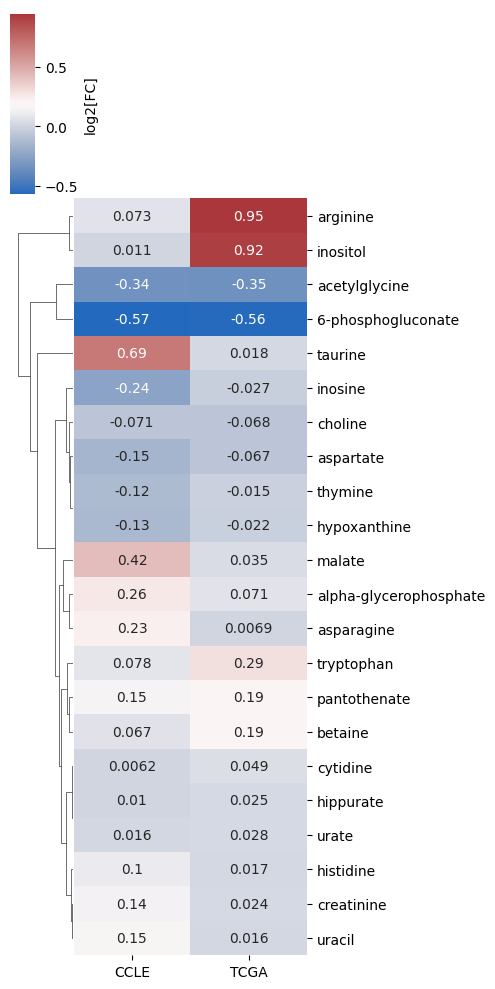

In [75]:
sns.clustermap(data = log2fc, cmap = cmap, col_cluster = False, figsize = (5,10), annot = True)
plt.ylabel('log2[FC]')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/CCLE_TCGA_log2FC_metabolites_heatmap.svg', bbox_inches = 'tight')

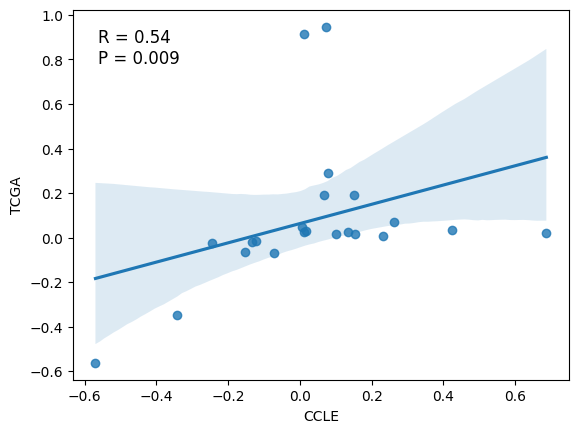

In [76]:
from scipy.stats import spearmanr

sns.regplot(data = log2fc, x = 'CCLE', y = 'TCGA')

# Add annotations
# for i in range(len(log2fc)):
#     plt.annotate(log2fc.index[i], (log2fc['CCLE'].iloc[i], log2fc['TCGA'].iloc[i]), textcoords="offset points", xytext=(0,10), ha='center')

# Calculate and add regression R and p-value
r, p_val = spearmanr(log2fc['CCLE'], log2fc['TCGA'])
plt.text(0.05, 0.95, f'R = {r:.2f}\nP = {p_val:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/CCLE_TCGA_log2FC_metabolites_corr_plot.svg', bbox_inches = 'tight')

plt.show()

#ssPA

In [77]:
!pip install gseapy
import gseapy as gp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.3/605.3 kB 10.0 MB/s eta 0:00:00


In [78]:
met_db = pd.read_csv('drive/My Drive/Colab Notebooks/pathbank_pathway_hmdb.csv')
met_db = met_db.dropna()
met_db

,Pathway Name,HMDB ID
0,Alanine Metabolism,HMDB0000538
1,Alanine Metabolism,HMDB0000161
2,Alanine Metabolism,HMDB0000045
3,Alanine Metabolism,HMDB0000250
4,Alanine Metabolism,HMDB0001303
...,...,...
1977776,Methylglyoxal Degradation I,HMDB0000190
1977777,Methylglyoxal Degradation I,HMDB0015532
1977778,Methylglyoxal Degradation I,HMDB0036062
1977779,Methylglyoxal Degradation I,HMDB0000243


In [79]:
len(met_db['Pathway Name'].unique())

68355

In [80]:
met_db_dict = met_db.groupby('Pathway Name')['HMDB ID'].apply(list).to_dict()
len(met_db_dict)

68355

In [81]:
metabolomics.head(3)

,MUT_status,2-aminoadipate,3-phosphoglycerate,alpha-glycerophosphate,4-pyridoxate,aconitate,adenine,adipate,alpha-ketoglutarate,AMP,...,C56:8 TAG,C56:7 TAG,C56:6 TAG,C56:5 TAG,C56:4 TAG,C56:3 TAG,C56:2 TAG,C58:8 TAG,C58:7 TAG,C58:6 TAG
ACH-000927,MUT,5.537100,5.728618,5.735934,5.983348,5.678932,5.603314,5.984889,5.782545,6.050206,...,6.077318,5.819687,5.887620,5.736615,5.847289,5.536305,5.415971,5.965816,5.942640,6.010368
ACH-000276,MUT,5.734549,5.741243,5.726934,5.558014,5.837319,6.174542,5.922278,5.751083,5.778905,...,5.820197,5.677272,6.063834,6.202897,6.425648,6.211892,6.210392,5.923512,5.915983,6.130336
ACH-000097,MUT,5.666087,6.212810,6.223117,6.116608,6.021599,6.018505,5.875382,6.097603,6.608236,...,5.776225,5.602235,5.733102,5.669476,5.921573,6.236516,6.380548,5.537621,5.940163,5.498613


In [82]:
metabolites_hmdb = metabolomics.rename(columns = map_names_dict)
metabolites_hmdb = metabolites_hmdb.drop(labels = np.nan, axis = 'columns')
metabolites_hmdb.head(2)

,MUT_status,HMDB0000510,HMDB0000807,HMDB0000126,HMDB0000017,HMDB0000072,HMDB0000034,HMDB0000448,HMDB0000208,HMDB0000045,...,HMDB0002095,HMDB0000756,HMDB0013238,HMDB0002250,HMDB0254979,HMDB0000222,HMDB0000848,HMDB0000271,HMDB0000056,HMDB0000194
ACH-000927,MUT,5.537100,5.728618,5.735934,5.983348,5.678932,5.603314,5.984889,5.782545,6.050206,...,6.577873,6.425343,6.457353,6.703316,6.783681,6.951486,6.802866,5.983781,5.607876,6.122318
ACH-000276,MUT,5.734549,5.741243,5.726934,5.558014,5.837319,6.174542,5.922278,5.751083,5.778905,...,5.736748,6.060952,6.044479,6.897217,6.752492,6.774580,7.110707,6.166067,6.226396,6.146434


In [83]:
#This function performs ssgsea and returns the results

def perform_sspa(df, gene_set_library):
  result = pd.DataFrame()

  for sample_id in df.columns:
    sample = df[sample_id]
    ssgsea_results = gp.ssgsea(data=sample, gene_sets=gene_set_library, outdir=None, min_size = 5)
    enrichment_scores = ssgsea_results.res2d
    sample_result = pd.DataFrame()
    for i in enrichment_scores['Name'].unique():
      sample_es = enrichment_scores[enrichment_scores['Name'] == i]
      sample_es = sample_es.rename(columns = {'Term' : ''})
      sample_es = sample_es.set_index('')
      sample_es = sample_es.drop(columns = ['Name', 'ES'])
      sample_es = sample_es.rename(columns = {'NES' : i})
      sample_result = pd.concat([sample_result, sample_es], axis = 'columns')
    result = pd.concat([result, sample_result], axis = 'columns')

  return result

sspa_res = perform_sspa(df = metabolites_hmdb.iloc[:, 1:].T, gene_set_library = met_db_dict)
sspa_res

,ACH-000927,ACH-000276,ACH-000097,ACH-000277,ACH-000374,ACH-000699,ACH-000721,ACH-000536,ACH-000668,ACH-000111,...,ACH-000643,ACH-000711,ACH-000759,ACH-000330,ACH-000147,ACH-000621,ACH-000857,ACH-000902,ACH-000818,ACH-000196
,,,,,,,,,,,,,,,,,,,,,
Glycolate and Glyoxylate Degradation II,-0.525972,-0.268983,0.482149,0.098568,-0.624158,-0.40007,-0.361622,0.299867,0.095258,-0.442958,...,0.3543,0.30774,-0.466538,-0.516831,0.268791,-0.091376,-0.016707,-0.329843,-0.076484,-0.135988
The Oncogenic Action of Succinate,-0.508545,-0.137367,0.306884,0.146351,-0.485798,-0.109817,-0.302909,0.419884,0.113735,-0.242523,...,0.078903,0.340142,-0.322493,-0.554384,0.237739,-0.106238,-0.206451,-0.325839,-0.296054,0.101909
The Oncogenic Action of Fumarate,-0.508545,-0.137367,0.306884,0.146351,-0.485798,-0.109817,-0.302909,0.419884,0.113735,-0.242523,...,0.078903,0.340142,-0.322493,-0.554384,0.237739,-0.106238,-0.206451,-0.325839,-0.296054,0.101909
Secondary Metabolites: Glyoxylate Cycle,-0.504302,-0.212666,0.422109,0.028584,-0.590376,-0.301386,-0.502566,0.383062,-0.101016,-0.697207,...,0.423051,0.195803,-0.523141,-0.506174,0.243374,-0.09763,-0.097636,-0.272846,-0.071175,-0.176345
Pyruvate Dehydrogenase Deficiency (E3),-0.490431,-0.25452,0.46549,0.008234,-0.586737,-0.346525,-0.428449,0.447857,-0.153049,-0.587705,...,0.334143,0.271615,-0.505578,-0.505358,0.302826,-0.187602,-0.044145,-0.283205,-0.15436,-0.194497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Hyperprolinemia Type II,-0.008922,0.242608,0.367265,0.128694,-0.011406,0.275698,-0.16612,0.027074,0.268033,-0.089045,...,-0.345554,0.085268,0.0227,-0.126076,0.237117,0.14271,0.085185,-0.172099,-0.103228,0.010015
"Creatine Deficiency, Guanidinoacetate Methyltransferase Deficiency",-0.008922,0.242608,0.367265,0.128694,-0.011406,0.275698,-0.16612,0.027074,0.268033,-0.089045,...,-0.345554,0.085268,0.0227,-0.126076,0.237117,0.14271,0.085185,-0.172099,-0.103228,0.010015
Hyperornithinemia-Hyperammonemia-Homocitrullinuria (HHH-syndrome),-0.008922,0.242608,0.367265,0.128694,-0.011406,0.275698,-0.16612,0.027074,0.268033,-0.089045,...,-0.345554,0.085268,0.0227,-0.126076,0.237117,0.14271,0.085185,-0.172099,-0.103228,0.010015


In [84]:
sspa_res = sspa_res.fillna(0)

/tmp/ipython-input-1383940723.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sspa_res = sspa_res.fillna(0)


In [85]:
keep_cols = ['Gluconeogenesis',
 'Phenylalanine Metabolism',
 'Purine Ribonucleosides Degradation',
 'Glycerol Metabolism II',
 'Glycerol Metabolism',
 'Tyrosine Biosynthesis',
 'Glycine Metabolism',
 'Secondary Metabolites: Valine and L-Leucine Biosynthesis from Pyruvate',
 'Biotin Metabolism',
 'Isoleucine Biosynthesis',
 'Isoleucine Biosynthesis ',
 'Sulfur Metabolism',
 'Gluconeogenesis from L-Malic Acid ',
 'Inner Membrane Transport',
 'Carnitine Synthesis',
 'Warburg Effect',
 'Valine, Leucine, and Isoleucine Degradation',
 'Phenylalanine and Tyrosine Metabolism',
 'Pyruvate Metabolism',
 'Propanoate Metabolism',
 'Glutathione Metabolism',
 'Alanine Metabolism',
 'Tyrosine Metabolism',
 'The Oncogenic Action of Fumarate',
 'The Oncogenic Action of Succinate',
 'Citrate Cycle',
 'Lysine Degradation',
 'One Carbon Pool by Folate',
 'One Carbon Pool by Folate I ',
 'Serine Metabolism',
 'Secondary Metabolites: Cysteine Biosynthesis from Serine',
 'Cysteine Biosynthesis ',
 'Glycolate and Glyoxylate Degradation II',
 'Threonine Metabolism',
 'Threonine Biosynthesis',
 'Serine Biosynthesis and Metabolism',
 'TCA Cycle',
 'NAD Metabolism',
 'Lysine Biosynthesis',
 'Citric Acid Cycle',
 'Glycine and Serine Metabolism',
 'Bile Acid Biosynthesis',
 'Methionine Metabolism and Salvage',
 'Lysine Metabolism',
 'Starch and Sucrose Metabolism',
 'Peptidoglycan Biosynthesis II',
 'Peptidoglycan Biosynthesis I',
 'Cysteine Metabolism',
 'Glutaminolysis and Cancer',
 'Disulfiram Action Pathway',
 'Butanoate Metabolism',
 'Porphyrin Metabolism',
 'Fructose Metabolism',
 'Aspartate Metabolism ',
 'Amino Sugar and Nucleotide Sugar Metabolism I',
 'Glutamic Acid Metabolism',
 'NAD Salvage',
 'Nitrogen Metabolism',
 'Secondary Metabolites: Glyoxylate Cycle',
 'Choline Metabolism',
 'beta-Alanine Metabolism',
 'Pantothenate and CoA Biosynthesis ',
 'Glutaric Aciduria Type I',
 'Glycine Betaine Biosynthesis II',
 'Glutamine Metabolism',
 'Histidine Metabolism',
 'Tryptophan Metabolism',
 'Methionine Metabolism',
 'AMP Degradation (Hypoxanthine Route)',
 'Ornithine Metabolism',
 'Secondary Metabolites: Histidine Biosynthesis',
 'Nicotinate and Nicotinamide Metabolism',
 'Pyrimidine Metabolism',
 'Purine Metabolism',
 'Adenosine Nucleotides Degradation ',
 'NAD Biosynthesis',
 'Asparagine Metabolism',
 'Asparagine Biosynthesis',
 'Pantothenate and CoA Biosynthesis',
 'Lipopolysaccharide Biosynthesis III',
 'Lipopolysaccharide Biosynthesis II',
 'Lipopolysaccharide Biosynthesis',
 'Sarcosine Oncometabolite Pathway ',
 'Betaine Metabolism',
 'Selenoamino Acid Metabolism',
 'Arginine Metabolism',
 'Fatty Acid Metabolism',
 'Arginine and Proline Metabolism',
 'Proline Metabolism',
 'L-Glutamate Metabolism',
 'Histidine Biosynthesis',
 'S-Adenosyl-L-Methionine Cycle',
 'Urea Cycle',
 'Phospholipid Biosynthesis',
 'Ammonia Recycling',
 'Purine Nucleotides De Novo Biosynthesis',
 'Glutamate Metabolism',
 'Tryptophan Metabolism II',
 'Aspartate Metabolism',
 'Galactose Metabolism']
sspa_res_keep_cols = sspa_res.reindex(keep_cols, axis = 'index').T
sspa_res_keep_cols = sspa_res_keep_cols.dropna(how = 'all', axis = 'columns')
sspa_res_keep_cols = pd.concat([metabolomics[['MUT_status']], sspa_res_keep_cols], axis = 'columns')
sspa_res_keep_cols.head(2)

,MUT_status,Gluconeogenesis,Phenylalanine Metabolism,Purine Ribonucleosides Degradation,Glycerol Metabolism II,Glycerol Metabolism,Tyrosine Biosynthesis,Glycine Metabolism,Secondary Metabolites: Valine and L-Leucine Biosynthesis from Pyruvate,Biotin Metabolism,...,Histidine Biosynthesis,S-Adenosyl-L-Methionine Cycle,Urea Cycle,Phospholipid Biosynthesis,Ammonia Recycling,Purine Nucleotides De Novo Biosynthesis,Glutamate Metabolism,Tryptophan Metabolism II,Aspartate Metabolism,Galactose Metabolism
ACH-000927,MUT,-0.365571,0.087862,0.264238,-0.178726,-0.125919,0.077783,0.130578,0.118118,0.398034,...,0.067314,0.140350,-0.037340,-0.051414,0.137652,0.073154,-0.108995,0.262015,-0.192982,-0.103279
ACH-000276,MUT,-0.376040,-0.442062,-0.211933,-0.336351,-0.396310,-0.359057,-0.384756,-0.408394,-0.300218,...,-0.210312,0.169604,0.110933,-0.038740,0.071286,-0.152577,-0.016499,0.178713,0.191631,-0.443147


In [86]:
sspa_res_keep_cols_grouped = sspa_res_keep_cols.groupby('MUT_status').median().T
sspa_res_keep_cols_grouped

MUT_status,MUT,WT
Gluconeogenesis,0.205217,0.024793
Phenylalanine Metabolism,-0.121406,-0.167437
Purine Ribonucleosides Degradation,-0.182168,0.224026
Glycerol Metabolism II,0.064066,-0.031432
Glycerol Metabolism,0.147576,-0.052512
...,...,...
Purine Nucleotides De Novo Biosynthesis,0.064432,-0.005538
Glutamate Metabolism,0.014346,0.036164
Tryptophan Metabolism II,0.128005,0.120687
Aspartate Metabolism,0.073886,-0.046809


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


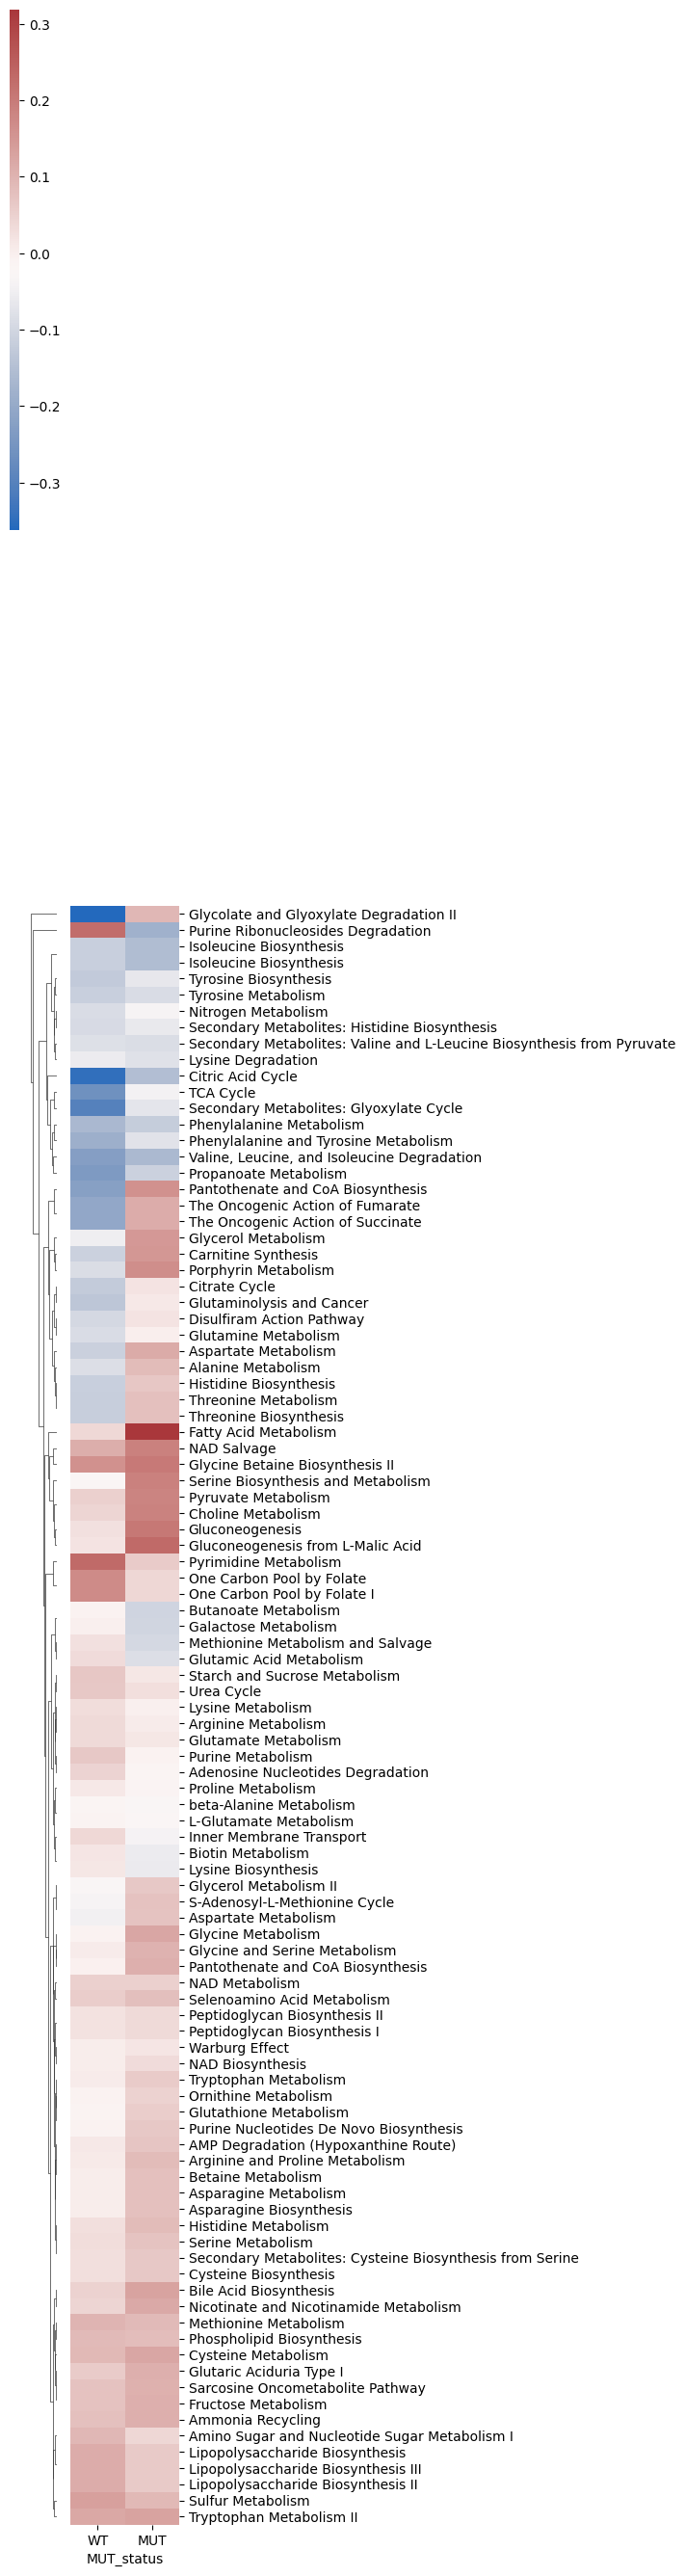

In [87]:
g = sns.clustermap(sspa_res_keep_cols_grouped[['WT', 'MUT']], cmap = cmap, figsize = (2,30), col_cluster = False)

In [88]:
keep_cols_tcga = ['Aspartate Metabolism', 'Glutaminolysis and Cancer',
       'Inner Membrane Transport', 'NAD Metabolism', 'beta-Alanine Metabolism',
       'Urea Cycle',  'Warburg Effect',
       'Arginine and Proline Metabolism',
       'Proline Metabolism', 'Arginine Metabolism',
       'Glycine and Serine Metabolism',
       'Purine Metabolism',
       'Methionine Metabolism', 'Tryptophan Metabolism',
       'Pyrimidine Metabolism',
       'Lysolipid Incorporation into ER PC(16:0/16:0)',
       'Nicotinate and Nicotinamide Metabolism']
sspa_res_keep_cols_tcga = sspa_res.reindex(keep_cols_tcga, axis = 'index').T
sspa_res_keep_cols_tcga = sspa_res_keep_cols_tcga.dropna(how = 'all', axis = 'columns')
sspa_res_keep_cols_tcga = pd.concat([metabolomics[['MUT_status']], sspa_res_keep_cols_tcga], axis = 'columns')
sspa_res_keep_cols_tcga.head(2)

,MUT_status,Aspartate Metabolism,Glutaminolysis and Cancer,Inner Membrane Transport,NAD Metabolism,beta-Alanine Metabolism,Urea Cycle,Warburg Effect,Arginine and Proline Metabolism,Proline Metabolism,Arginine Metabolism,Glycine and Serine Metabolism,Purine Metabolism,Methionine Metabolism,Tryptophan Metabolism,Pyrimidine Metabolism,Nicotinate and Nicotinamide Metabolism
ACH-000927,MUT,-0.192982,-0.226969,0.275218,0.263104,-0.027354,-0.037340,-0.316444,-0.008922,-0.077585,-0.120091,0.132973,0.106949,0.244419,0.195417,-0.468145,0.187607
ACH-000276,MUT,0.191631,-0.247568,-0.092017,-0.181514,0.139860,0.110933,-0.303964,0.242608,0.098020,0.133637,0.002327,-0.302975,-0.026017,0.021396,0.289449,-0.348623


In [89]:
sspa_res_keep_cols_tcga_grouped = sspa_res_keep_cols_tcga.groupby('MUT_status').median().T
sspa_res_keep_cols_tcga_grouped

MUT_status,MUT,WT
Aspartate Metabolism,0.073886,-0.046809
Glutaminolysis and Cancer,0.013027,-0.134684
Inner Membrane Transport,-0.041113,0.038181
NAD Metabolism,0.050958,0.050963
beta-Alanine Metabolism,-0.027354,-0.014418
Urea Cycle,0.026712,0.065188
Warburg Effect,0.017139,0.003446
Arginine and Proline Metabolism,0.085268,0.010015
Proline Metabolism,-0.012749,0.010970
Arginine Metabolism,0.006716,0.035268


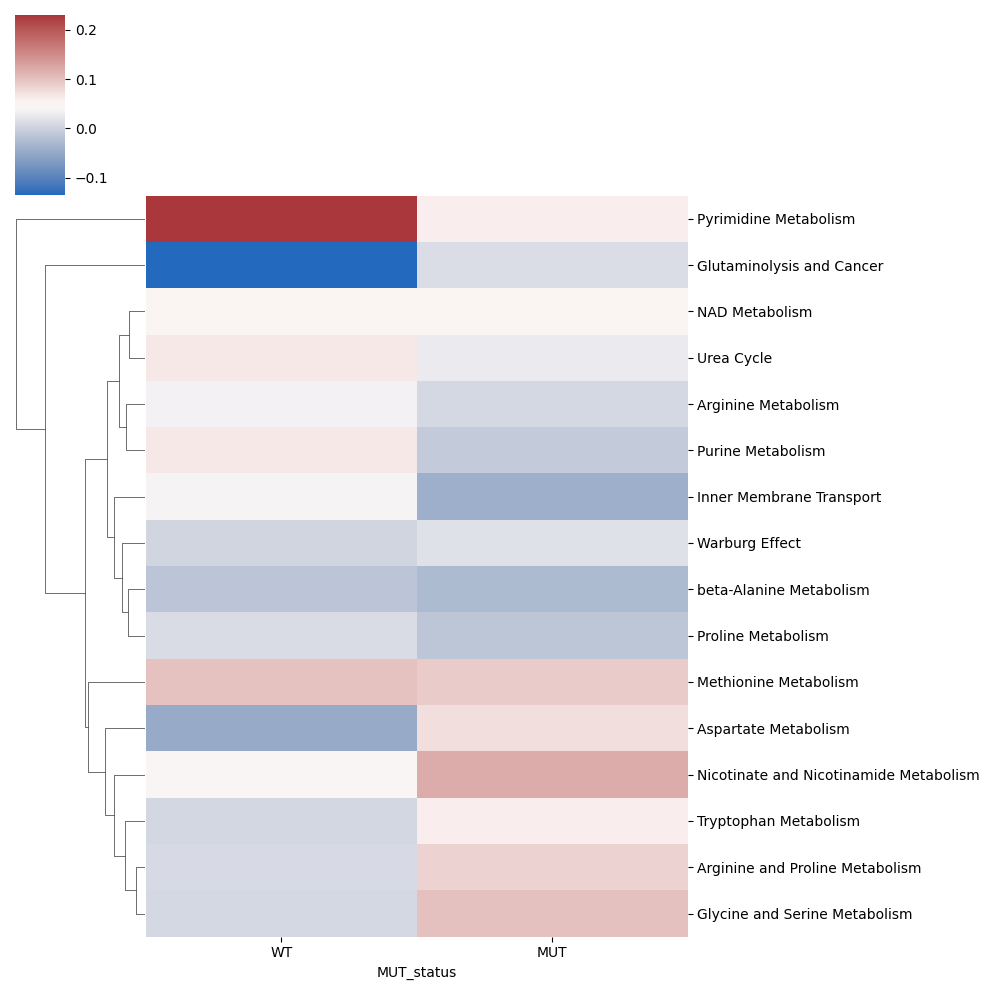

In [90]:
g = sns.clustermap(sspa_res_keep_cols_tcga_grouped[['WT', 'MUT']], cmap = cmap, col_cluster = False)
g.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/CCLE_clustermap_ssPA.svg', format='svg')

In [91]:
add_pseudo = sspa_res_keep_cols_tcga_grouped + 1
sspa_res_keep_cols_tcga_grouped['log2FC'] = np.log2(add_pseudo['MUT'] / add_pseudo['WT'])
sspa_res_keep_cols_tcga_grouped = sspa_res_keep_cols_tcga_grouped.rename(columns = {'log2FC' : 'CCLE'})
sspa_res_keep_cols_tcga_grouped

MUT_status,MUT,WT,CCLE
Aspartate Metabolism,0.073886,-0.046809,0.172003
Glutaminolysis and Cancer,0.013027,-0.134684,0.227375
Inner Membrane Transport,-0.041113,0.038181,-0.114625
NAD Metabolism,0.050958,0.050963,-0.000008
beta-Alanine Metabolism,-0.027354,-0.014418,-0.019061
Urea Cycle,0.026712,0.065188,-0.053077
Warburg Effect,0.017139,0.003446,0.019555
Arginine and Proline Metabolism,0.085268,0.010015,0.103674
Proline Metabolism,-0.012749,0.010970,-0.034251
Arginine Metabolism,0.006716,0.035268,-0.040347


In [92]:
tcga_log2fc_sspa = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/log2fc_ssPA_tcga.csv', index_col = 0).rename(columns = {'log2FC' : 'TCGA'})
tcga_log2fc_sspa

,TCGA
Lysolipid Incorporation into ER PC(16:0/16:0),0.279633
beta-Alanine Metabolism,0.119524
Inner Membrane Transport,0.091993
Arginine and Proline Metabolism,0.089051
Nicotinate and Nicotinamide Metabolism,0.069966
Proline Metabolism,0.040313
Arginine Metabolism,0.040313
Glutaminolysis and Cancer,0.038011
Aspartate Metabolism,0.036511
Urea Cycle,0.032968


In [93]:
c_index = list(
    set(sspa_res_keep_cols_tcga_grouped.index).intersection(set(tcga_log2fc_sspa.index))
)
log2fc_sspa = pd.concat([sspa_res_keep_cols_tcga_grouped.loc[c_index][['CCLE']], tcga_log2fc_sspa.loc[c_index]], axis = 'columns')
log2fc_sspa

,CCLE,TCGA
Arginine Metabolism,-0.040347,0.040313
Warburg Effect,0.019555,-0.001620
Glutaminolysis and Cancer,0.227375,0.038011
Arginine and Proline Metabolism,0.103674,0.089051
Inner Membrane Transport,-0.114625,0.091993
Pyrimidine Metabolism,-0.215252,-0.794063
beta-Alanine Metabolism,-0.019061,0.119524
Tryptophan Metabolism,0.074660,-0.094851
Aspartate Metabolism,0.172003,0.036511
Urea Cycle,-0.053077,0.032968


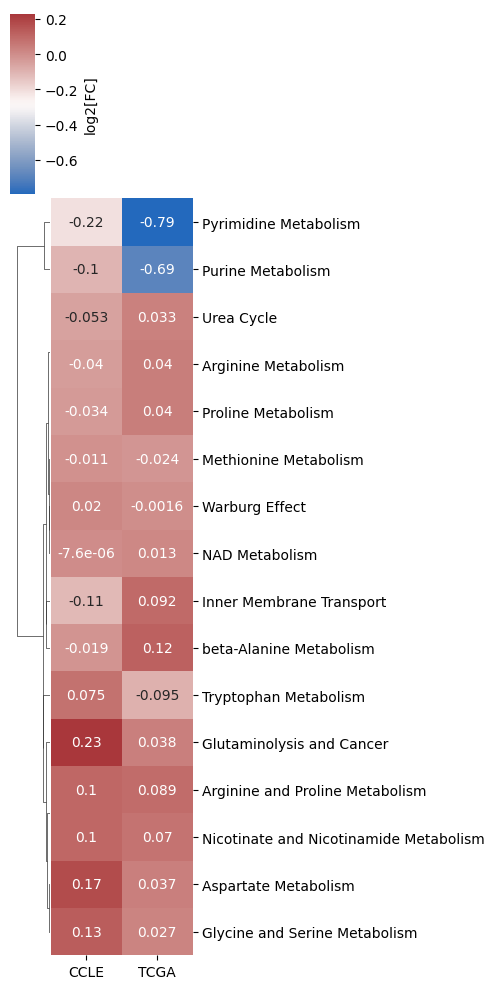

In [94]:
sns.clustermap(data = log2fc_sspa, cmap = cmap, col_cluster = False, figsize = (5,10), annot = True)
plt.ylabel('log2[FC]')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/CCLE_TCGA_log2FC_ssPA_heatmap.svg', bbox_inches = 'tight')

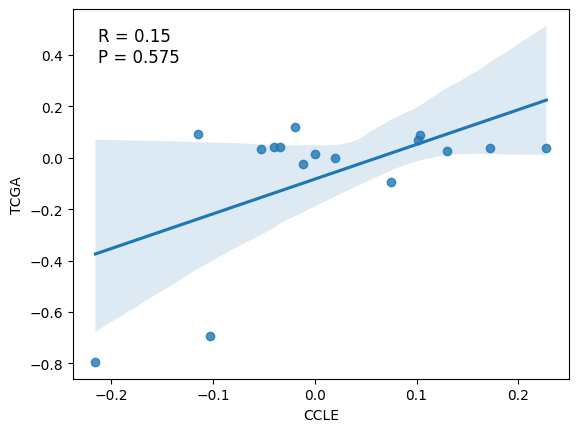

In [95]:
sns.regplot(data = log2fc_sspa, x = 'CCLE', y = 'TCGA')

# Add annotations
# for i in range(len(log2fc_sspa)):
#     plt.annotate(log2fc_sspa.index[i], (log2fc_sspa['CCLE'].iloc[i], log2fc_sspa['TCGA'].iloc[i]), textcoords="offset points", xytext=(0,10), ha='center')

# Calculate and add regression R and p-value
r, p_val = spearmanr(log2fc_sspa['CCLE'], log2fc_sspa['TCGA'])
plt.text(0.05, 0.95, f'R = {r:.2f}\nP = {p_val:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/CCLE_TCGA_log2FC_ssPA_corr_plot.svg', bbox_inches = 'tight')
plt.show()

#PI3K isogenics validation

In [96]:
lcms = pd.read_excel('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/MCF10A_MCF7_LCMS_normalized.xlsx', index_col = 0)
lcms

,adenine,glycodeoxycholate/glycochenodeoxycholate,xanthine,uracil,uridine,allantoin,guanosine,phenylalanine,leucine,methionine,...,thymine,malate,fumarate/maleate/alpha-ketoisovalerate,cystathionine,ornithine,arginine,phosphocreatine,lysine,acetylcholine,glutathione oxidized
MCF7_WT_1,23002.022452,2142.219452,97688.857527,27255.491671,67257.925918,28046.789550,2567.790792,309617.175892,130700.222142,441523.046353,...,850615.222659,2.567951e+06,1.391936e+06,114626.731505,59448.179410,160682.616968,57519.531092,1.964300e+06,74.880807,124394.749509
MCF7_WT_2,15809.205927,2969.287481,95390.115176,15967.105876,74292.775677,24371.786919,4203.374962,249592.899949,150673.938886,503829.477057,...,590604.328666,1.640272e+06,9.373855e+05,74186.154420,55241.042207,156412.645171,26704.154624,1.770922e+06,NaN,94133.270005
MCF7_WT_3,17583.092659,1980.917781,124341.689396,17758.279608,91271.928874,35725.871452,3014.898206,292876.645677,124017.892333,494630.680261,...,74.776835,2.200092e+06,1.214162e+06,110902.774551,77913.373573,213726.427080,50877.655465,2.646350e+06,NaN,167165.305710
MCF7_WT_4,27882.576427,2673.774437,117706.369408,21160.456469,87363.775065,29368.191828,1758.605657,284050.831116,159257.546778,636148.422525,...,776221.738083,1.871641e+06,1.087192e+06,112788.302986,67391.553379,184916.358512,47938.346464,2.416454e+06,NaN,172341.536511
MCF7_WT_5,16193.001569,2203.040216,99880.092006,13299.015890,67873.920942,25316.701324,1664.637469,202832.597155,184981.269740,561874.893575,...,482376.806278,1.356787e+06,7.794425e+05,51860.552428,45407.662187,130623.441981,19524.191270,1.532717e+06,NaN,86944.171751
MCF7_MUT_1,12817.736654,1170.918977,89399.483844,36876.569583,41606.777562,26003.459114,1841.968790,302534.561340,195118.911880,54951.760811,...,790590.125898,1.723339e+06,8.937987e+05,553918.012078,40071.506105,107976.074058,59378.713555,3.212703e+06,NaN,194039.973419
MCF7_MUT_2,11008.388658,1480.809189,78849.386935,59315.203733,43568.613209,19464.080402,8125.385068,315419.761953,193846.905384,157630.885571,...,786636.733381,9.451350e+05,4.443660e+05,565082.544149,31549.201005,84280.693037,60987.498062,2.633758e+06,29.445944,136970.317157
MCF7_MUT_3,20433.641563,1076.936672,91128.727077,30703.185678,52898.625790,20291.275029,2239.929464,296431.319775,170285.230658,196452.754599,...,702853.731055,2.108465e+06,1.079885e+06,478838.517669,32070.337561,85193.900445,45923.037866,2.591607e+06,NaN,207031.735268
MCF7_MUT_4,14985.659512,1468.727736,84889.685699,51260.946628,54458.424088,19963.754500,5462.434794,287387.282865,45600.336605,311574.677775,...,700030.341223,2.508575e+06,1.265175e+06,457551.242456,33742.225977,89052.997061,50121.410601,2.540307e+06,NaN,134900.720703
MCF7_MUT_5,9379.395922,1014.391513,76944.413337,40880.719096,55338.447892,16806.632075,4190.013117,278538.688619,61439.101571,391121.881786,...,22.831579,2.605629e+06,8.123404e+05,377129.192009,31343.653789,88684.467016,44576.526150,2.211152e+06,30.043648,97927.909452


In [97]:
mcf7_lcms = lcms.iloc[0:10, :]
mcf7_lcms

,adenine,glycodeoxycholate/glycochenodeoxycholate,xanthine,uracil,uridine,allantoin,guanosine,phenylalanine,leucine,methionine,...,thymine,malate,fumarate/maleate/alpha-ketoisovalerate,cystathionine,ornithine,arginine,phosphocreatine,lysine,acetylcholine,glutathione oxidized
MCF7_WT_1,23002.022452,2142.219452,97688.857527,27255.491671,67257.925918,28046.789550,2567.790792,309617.175892,130700.222142,441523.046353,...,850615.222659,2.567951e+06,1.391936e+06,114626.731505,59448.179410,160682.616968,57519.531092,1.964300e+06,74.880807,124394.749509
MCF7_WT_2,15809.205927,2969.287481,95390.115176,15967.105876,74292.775677,24371.786919,4203.374962,249592.899949,150673.938886,503829.477057,...,590604.328666,1.640272e+06,9.373855e+05,74186.154420,55241.042207,156412.645171,26704.154624,1.770922e+06,NaN,94133.270005
MCF7_WT_3,17583.092659,1980.917781,124341.689396,17758.279608,91271.928874,35725.871452,3014.898206,292876.645677,124017.892333,494630.680261,...,74.776835,2.200092e+06,1.214162e+06,110902.774551,77913.373573,213726.427080,50877.655465,2.646350e+06,NaN,167165.305710
MCF7_WT_4,27882.576427,2673.774437,117706.369408,21160.456469,87363.775065,29368.191828,1758.605657,284050.831116,159257.546778,636148.422525,...,776221.738083,1.871641e+06,1.087192e+06,112788.302986,67391.553379,184916.358512,47938.346464,2.416454e+06,NaN,172341.536511
MCF7_WT_5,16193.001569,2203.040216,99880.092006,13299.015890,67873.920942,25316.701324,1664.637469,202832.597155,184981.269740,561874.893575,...,482376.806278,1.356787e+06,7.794425e+05,51860.552428,45407.662187,130623.441981,19524.191270,1.532717e+06,NaN,86944.171751
MCF7_MUT_1,12817.736654,1170.918977,89399.483844,36876.569583,41606.777562,26003.459114,1841.968790,302534.561340,195118.911880,54951.760811,...,790590.125898,1.723339e+06,8.937987e+05,553918.012078,40071.506105,107976.074058,59378.713555,3.212703e+06,NaN,194039.973419
MCF7_MUT_2,11008.388658,1480.809189,78849.386935,59315.203733,43568.613209,19464.080402,8125.385068,315419.761953,193846.905384,157630.885571,...,786636.733381,9.451350e+05,4.443660e+05,565082.544149,31549.201005,84280.693037,60987.498062,2.633758e+06,29.445944,136970.317157
MCF7_MUT_3,20433.641563,1076.936672,91128.727077,30703.185678,52898.625790,20291.275029,2239.929464,296431.319775,170285.230658,196452.754599,...,702853.731055,2.108465e+06,1.079885e+06,478838.517669,32070.337561,85193.900445,45923.037866,2.591607e+06,NaN,207031.735268
MCF7_MUT_4,14985.659512,1468.727736,84889.685699,51260.946628,54458.424088,19963.754500,5462.434794,287387.282865,45600.336605,311574.677775,...,700030.341223,2.508575e+06,1.265175e+06,457551.242456,33742.225977,89052.997061,50121.410601,2.540307e+06,NaN,134900.720703
MCF7_MUT_5,9379.395922,1014.391513,76944.413337,40880.719096,55338.447892,16806.632075,4190.013117,278538.688619,61439.101571,391121.881786,...,22.831579,2.605629e+06,8.123404e+05,377129.192009,31343.653789,88684.467016,44576.526150,2.211152e+06,30.043648,97927.909452


In [98]:
mcf7_lcms.drop(columns = ['acetylcholine', 'lactate', 'kynurenic acid'], inplace = True)
mcf7_lcms

/tmp/ipython-input-2874828450.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mcf7_lcms.drop(columns = ['acetylcholine', 'lactate', 'kynurenic acid'], inplace = True)


,adenine,glycodeoxycholate/glycochenodeoxycholate,xanthine,uracil,uridine,allantoin,guanosine,phenylalanine,leucine,methionine,...,NAD,thymine,malate,fumarate/maleate/alpha-ketoisovalerate,cystathionine,ornithine,arginine,phosphocreatine,lysine,glutathione oxidized
MCF7_WT_1,23002.022452,2142.219452,97688.857527,27255.491671,67257.925918,28046.789550,2567.790792,309617.175892,130700.222142,441523.046353,...,12698.019452,850615.222659,2.567951e+06,1.391936e+06,114626.731505,59448.179410,160682.616968,57519.531092,1.964300e+06,124394.749509
MCF7_WT_2,15809.205927,2969.287481,95390.115176,15967.105876,74292.775677,24371.786919,4203.374962,249592.899949,150673.938886,503829.477057,...,7951.152785,590604.328666,1.640272e+06,9.373855e+05,74186.154420,55241.042207,156412.645171,26704.154624,1.770922e+06,94133.270005
MCF7_WT_3,17583.092659,1980.917781,124341.689396,17758.279608,91271.928874,35725.871452,3014.898206,292876.645677,124017.892333,494630.680261,...,13662.223165,74.776835,2.200092e+06,1.214162e+06,110902.774551,77913.373573,213726.427080,50877.655465,2.646350e+06,167165.305710
MCF7_WT_4,27882.576427,2673.774437,117706.369408,21160.456469,87363.775065,29368.191828,1758.605657,284050.831116,159257.546778,636148.422525,...,12548.159246,776221.738083,1.871641e+06,1.087192e+06,112788.302986,67391.553379,184916.358512,47938.346464,2.416454e+06,172341.536511
MCF7_WT_5,16193.001569,2203.040216,99880.092006,13299.015890,67873.920942,25316.701324,1664.637469,202832.597155,184981.269740,561874.893575,...,5677.340657,482376.806278,1.356787e+06,7.794425e+05,51860.552428,45407.662187,130623.441981,19524.191270,1.532717e+06,86944.171751
MCF7_MUT_1,12817.736654,1170.918977,89399.483844,36876.569583,41606.777562,26003.459114,1841.968790,302534.561340,195118.911880,54951.760811,...,11864.721622,790590.125898,1.723339e+06,8.937987e+05,553918.012078,40071.506105,107976.074058,59378.713555,3.212703e+06,194039.973419
MCF7_MUT_2,11008.388658,1480.809189,78849.386935,59315.203733,43568.613209,19464.080402,8125.385068,315419.761953,193846.905384,157630.885571,...,7041.213783,786636.733381,9.451350e+05,4.443660e+05,565082.544149,31549.201005,84280.693037,60987.498062,2.633758e+06,136970.317157
MCF7_MUT_3,20433.641563,1076.936672,91128.727077,30703.185678,52898.625790,20291.275029,2239.929464,296431.319775,170285.230658,196452.754599,...,9338.797941,702853.731055,2.108465e+06,1.079885e+06,478838.517669,32070.337561,85193.900445,45923.037866,2.591607e+06,207031.735268
MCF7_MUT_4,14985.659512,1468.727736,84889.685699,51260.946628,54458.424088,19963.754500,5462.434794,287387.282865,45600.336605,311574.677775,...,10418.636788,700030.341223,2.508575e+06,1.265175e+06,457551.242456,33742.225977,89052.997061,50121.410601,2.540307e+06,134900.720703
MCF7_MUT_5,9379.395922,1014.391513,76944.413337,40880.719096,55338.447892,16806.632075,4190.013117,278538.688619,61439.101571,391121.881786,...,8320.337393,22.831579,2.605629e+06,8.123404e+05,377129.192009,31343.653789,88684.467016,44576.526150,2.211152e+06,97927.909452


In [99]:
mcf7_lcms['PI3K'] = [i.split('_')[1] for i in mcf7_lcms.index.to_list()]
mcf7_lcms

/tmp/ipython-input-463333992.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mcf7_lcms['PI3K'] = [i.split('_')[1] for i in mcf7_lcms.index.to_list()]


,adenine,glycodeoxycholate/glycochenodeoxycholate,xanthine,uracil,uridine,allantoin,guanosine,phenylalanine,leucine,methionine,...,thymine,malate,fumarate/maleate/alpha-ketoisovalerate,cystathionine,ornithine,arginine,phosphocreatine,lysine,glutathione oxidized,PI3K
MCF7_WT_1,23002.022452,2142.219452,97688.857527,27255.491671,67257.925918,28046.789550,2567.790792,309617.175892,130700.222142,441523.046353,...,850615.222659,2.567951e+06,1.391936e+06,114626.731505,59448.179410,160682.616968,57519.531092,1.964300e+06,124394.749509,WT
MCF7_WT_2,15809.205927,2969.287481,95390.115176,15967.105876,74292.775677,24371.786919,4203.374962,249592.899949,150673.938886,503829.477057,...,590604.328666,1.640272e+06,9.373855e+05,74186.154420,55241.042207,156412.645171,26704.154624,1.770922e+06,94133.270005,WT
MCF7_WT_3,17583.092659,1980.917781,124341.689396,17758.279608,91271.928874,35725.871452,3014.898206,292876.645677,124017.892333,494630.680261,...,74.776835,2.200092e+06,1.214162e+06,110902.774551,77913.373573,213726.427080,50877.655465,2.646350e+06,167165.305710,WT
MCF7_WT_4,27882.576427,2673.774437,117706.369408,21160.456469,87363.775065,29368.191828,1758.605657,284050.831116,159257.546778,636148.422525,...,776221.738083,1.871641e+06,1.087192e+06,112788.302986,67391.553379,184916.358512,47938.346464,2.416454e+06,172341.536511,WT
MCF7_WT_5,16193.001569,2203.040216,99880.092006,13299.015890,67873.920942,25316.701324,1664.637469,202832.597155,184981.269740,561874.893575,...,482376.806278,1.356787e+06,7.794425e+05,51860.552428,45407.662187,130623.441981,19524.191270,1.532717e+06,86944.171751,WT
MCF7_MUT_1,12817.736654,1170.918977,89399.483844,36876.569583,41606.777562,26003.459114,1841.968790,302534.561340,195118.911880,54951.760811,...,790590.125898,1.723339e+06,8.937987e+05,553918.012078,40071.506105,107976.074058,59378.713555,3.212703e+06,194039.973419,MUT
MCF7_MUT_2,11008.388658,1480.809189,78849.386935,59315.203733,43568.613209,19464.080402,8125.385068,315419.761953,193846.905384,157630.885571,...,786636.733381,9.451350e+05,4.443660e+05,565082.544149,31549.201005,84280.693037,60987.498062,2.633758e+06,136970.317157,MUT
MCF7_MUT_3,20433.641563,1076.936672,91128.727077,30703.185678,52898.625790,20291.275029,2239.929464,296431.319775,170285.230658,196452.754599,...,702853.731055,2.108465e+06,1.079885e+06,478838.517669,32070.337561,85193.900445,45923.037866,2.591607e+06,207031.735268,MUT
MCF7_MUT_4,14985.659512,1468.727736,84889.685699,51260.946628,54458.424088,19963.754500,5462.434794,287387.282865,45600.336605,311574.677775,...,700030.341223,2.508575e+06,1.265175e+06,457551.242456,33742.225977,89052.997061,50121.410601,2.540307e+06,134900.720703,MUT
MCF7_MUT_5,9379.395922,1014.391513,76944.413337,40880.719096,55338.447892,16806.632075,4190.013117,278538.688619,61439.101571,391121.881786,...,22.831579,2.605629e+06,8.123404e+05,377129.192009,31343.653789,88684.467016,44576.526150,2.211152e+06,97927.909452,MUT


In [100]:
log2fc

,CCLE,TCGA
arginine,0.073223,0.946148
alpha-glycerophosphate,0.261405,0.071399
tryptophan,0.077686,0.290592
cytidine,0.006244,0.049012
histidine,0.100398,0.017115
hippurate,0.010350,0.024858
pantothenate,0.150686,0.190163
creatinine,0.135106,0.023789
malate,0.423134,0.035331
uracil,0.153635,0.015979


In [101]:
mets_from_ccle_tcga = list((set(mcf7_lcms.columns.to_list()).intersection(set(log2fc.index.to_list()))))
mets_from_ccle_tcga

['malate',
 'histidine',
 'arginine',
 'uracil',
 'asparagine',
 'hypoxanthine',
 'creatinine',
 'aspartate',
 'thymine',
 'urate',
 'taurine',
 'betaine']

In [102]:
mcf7_lcms_selected = mcf7_lcms[['PI3K'] + mets_from_ccle_tcga]
mcf7_lcms_selected

,PI3K,malate,histidine,arginine,uracil,asparagine,hypoxanthine,creatinine,aspartate,thymine,urate,taurine,betaine
MCF7_WT_1,WT,2.567951e+06,3.343455e+06,160682.616968,27255.491671,51896.438800,356654.067253,506556.989860,402300.015830,850615.222659,6447.005587,3.762507e+06,1.733759e+06
MCF7_WT_2,WT,1.640272e+06,2.951346e+06,156412.645171,15967.105876,40656.170465,302245.402657,393226.732550,366651.587430,590604.328666,7892.928564,3.267898e+06,1.559546e+06
MCF7_WT_3,WT,2.200092e+06,3.455229e+06,213726.427080,17758.279608,46107.742577,333408.127896,450923.423491,400439.781403,74.776835,9198.966069,3.952858e+06,1.826012e+06
MCF7_WT_4,WT,1.871641e+06,3.122576e+06,184916.358512,21160.456469,41249.251964,315654.149607,462481.701624,367769.459089,776221.738083,7756.437926,3.715447e+06,1.766981e+06
MCF7_WT_5,WT,1.356787e+06,2.530818e+06,130623.441981,13299.015890,35827.256204,245050.691123,347602.585483,308835.105640,482376.806278,7086.038254,2.992985e+06,1.341716e+06
MCF7_MUT_1,MUT,1.723339e+06,2.147081e+06,107976.074058,36876.569583,108727.025171,488142.987481,358192.653471,135851.429094,790590.125898,19083.726030,1.900436e+06,1.576341e+06
MCF7_MUT_2,MUT,9.451350e+05,2.317565e+06,84280.693037,59315.203733,134223.401579,440104.373151,468760.951328,144449.552333,786636.733381,12719.575162,1.879838e+06,1.787295e+06
MCF7_MUT_3,MUT,2.108465e+06,2.097608e+06,85193.900445,30703.185678,119355.066698,356923.966674,431539.123333,158109.998643,702853.731055,11969.076340,1.669406e+06,1.608939e+06
MCF7_MUT_4,MUT,2.508575e+06,2.278387e+06,89052.997061,51260.946628,126322.271635,347193.288901,460796.945211,162847.184414,700030.341223,11075.085122,1.834209e+06,1.715357e+06
MCF7_MUT_5,MUT,2.605629e+06,2.116797e+06,88684.467016,40880.719096,110207.872196,282428.305098,393970.290603,172120.619454,22.831579,8100.747809,1.735580e+06,1.608147e+06


In [103]:
from sklearn.preprocessing import MinMaxScaler
scaler_mcf7 = MinMaxScaler(feature_range=(0,1))
mcf7_lcms_selected_scaled = pd.DataFrame(scaler_mcf7.fit_transform(mcf7_lcms_selected.iloc[:,1:]),
                                         columns = mcf7_lcms_selected.iloc[:,1:].columns,
                                         index = mcf7_lcms_selected.index)
mcf7_lcms_selected_scaled = pd.concat([mcf7_lcms_selected['PI3K'], mcf7_lcms_selected_scaled], axis = 'columns')
mcf7_lcms_selected_scaled

,PI3K,malate,histidine,arginine,uracil,asparagine,hypoxanthine,creatinine,aspartate,thymine,urate,taurine,betaine
MCF7_WT_1,WT,0.977309,0.917669,0.590224,0.303295,0.163311,0.459099,1.000000,1.000000,1.000000,0.000000,0.916639,0.809510
MCF7_WT_2,WT,0.418633,0.628849,0.557237,0.057982,0.049076,0.235280,0.287027,0.866209,0.694318,0.114422,0.700033,0.449787
MCF7_WT_3,WT,0.755773,1.000000,1.000000,0.096906,0.104481,0.363473,0.650003,0.993018,0.000061,0.217775,1.000000,1.000000
MCF7_WT_4,WT,0.557970,0.754973,0.777435,0.170841,0.055104,0.290439,0.722717,0.870404,0.912539,0.103621,0.896030,0.878110
MCF7_WT_5,WT,0.247909,0.319095,0.358009,0.000000,0.000000,0.000000,0.000000,0.649220,0.567080,0.050570,0.579639,0.000000
MCF7_MUT_1,MUT,0.468658,0.036442,0.183053,0.512375,0.740880,1.000000,0.066623,0.000000,0.929431,1.000000,0.101175,0.484467
MCF7_MUT_2,MUT,0.000000,0.162017,0.000000,1.000000,1.000000,0.802385,0.762221,0.032269,0.924784,0.496376,0.092155,0.920054
MCF7_MUT_3,MUT,0.700592,0.000000,0.007055,0.378218,0.848893,0.460209,0.528054,0.083538,0.826284,0.436986,0.000000,0.551775
MCF7_MUT_4,MUT,0.941551,0.133159,0.036867,0.824969,0.919701,0.420180,0.712118,0.101317,0.822965,0.366241,0.072172,0.771513
MCF7_MUT_5,MUT,1.000000,0.014135,0.034020,0.599391,0.755930,0.153759,0.291704,0.136121,0.000000,0.130868,0.028979,0.550140


In [104]:
mcf7_lcms_selected_scaled.to_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/mcf7_lcms_selected_scaled.csv')

In [105]:
from scipy.stats import ttest_ind
ttest = {}
for i in mcf7_lcms_selected_scaled.iloc[:, 1:].columns:
  stat, p_val = ttest_ind(mcf7_lcms_selected_scaled[mcf7_lcms_selected_scaled['PI3K'] == 'WT'][i],
                           mcf7_lcms_selected_scaled[mcf7_lcms_selected_scaled['PI3K'] == 'MUT'][i])
  ttest[i] = p_val
ttest = pd.DataFrame(ttest, index = ['p_value']).T.sort_values(by = 'p_value', ascending = False)
ttest

,p_value
malate,8.936741e-01
betaine,8.913397e-01
thymine,7.984383e-01
creatinine,7.911768e-01
hypoxanthine,1.147039e-01
urate,2.969134e-02
uracil,2.385450e-03
histidine,7.578158e-04
arginine,7.135641e-04
taurine,1.216436e-05


In [106]:
mcf7_lcms_selected_melted = mcf7_lcms_selected_scaled.melt(id_vars = ['PI3K'], value_vars = mcf7_lcms_selected_scaled.iloc[:, 1:].columns, var_name = 'metabolite', value_name = 'levels')
mcf7_lcms_selected_melted

,PI3K,metabolite,levels
0,WT,malate,0.977309
1,WT,malate,0.418633
2,WT,malate,0.755773
3,WT,malate,0.557970
4,WT,malate,0.247909
...,...,...,...
115,MUT,betaine,0.484467
116,MUT,betaine,0.920054
117,MUT,betaine,0.551775
118,MUT,betaine,0.771513


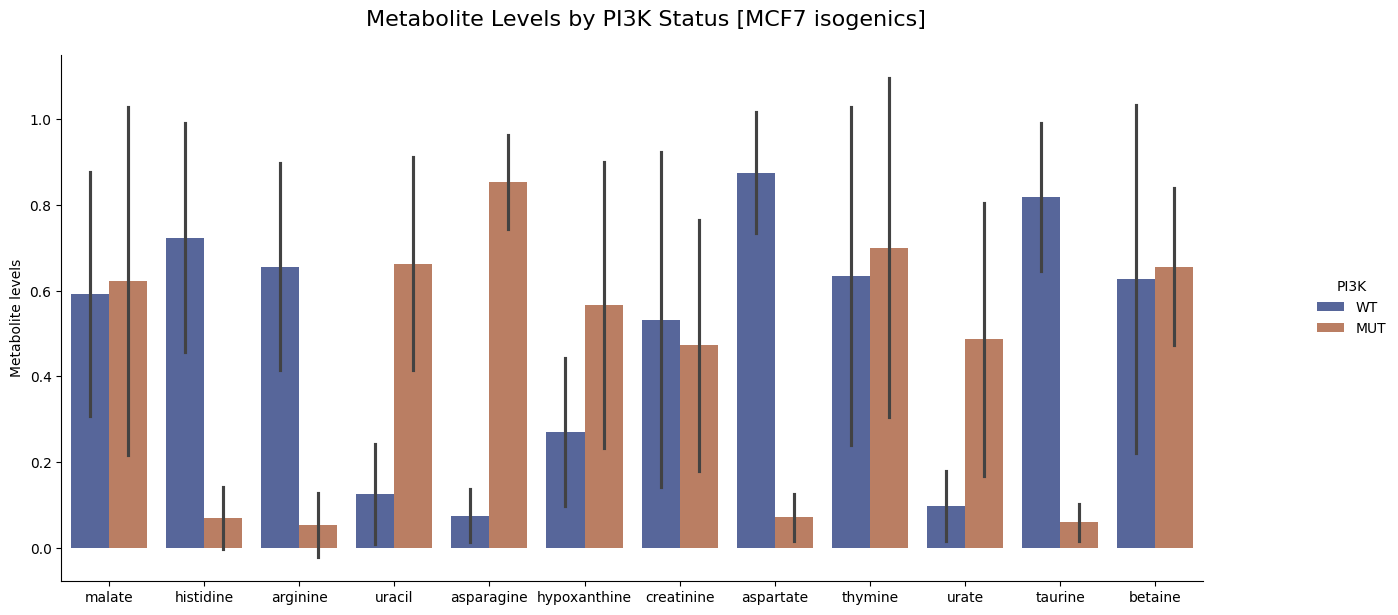

In [107]:
g = sns.catplot(
    data = mcf7_lcms_selected_melted,
    kind = 'bar',
    x = 'metabolite',
    y = 'levels',
    hue = 'PI3K',
    errorbar="sd",
    palette="dark",
    alpha=.7,
    height=6
)
# g.despine(left=True)
g.ax.grid(False)
g.set_axis_labels("", "Metabolite levels")
g.legend.set_title("PI3K")
g.fig.suptitle("Metabolite Levels by PI3K Status [MCF7 isogenics]", fontsize=16, y=1.05)
g.fig.set_size_inches(15, 6)
g.savefig("drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/metabolite_levels_PI3K.svg", bbox_inches='tight')